In [1]:
!pip install catboost -q

import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import os
import time

from sklearn.model_selection import (train_test_split, cross_val_score,
                                     StratifiedKFold, GridSearchCV,
                                     RandomizedSearchCV, learning_curve)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, roc_auc_score,
                             roc_curve, precision_recall_curve,
                             ConfusionMatrixDisplay,
                             average_precision_score)
from sklearn.inspection import permutation_importance

from catboost import (CatBoostClassifier, Pool,cv as catboost_cv)

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 120

import catboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.0 MB/s eta 0:00:00


In [2]:
path = kagglehub.dataset_download(
    "henriqueyamahata/bank-marketing")
print("📁 Path:", path)

# Try different file names
for fname in ["bank-additional-full.csv",
              "bank-additional.csv",
              "bank-full.csv",
              "bank.csv"]:
    fpath = os.path.join(path, fname)
    if os.path.exists(fpath):
        csv_file = fpath
        print(f"✅ Found: {fname}")
        break

df = pd.read_csv(csv_file, sep=';')

print(f"\n✅ Dataset Loaded!")
print(f"📐 Shape: {df.shape[0]:,} rows × "
      f"{df.shape[1]} columns")
df.head()

100%|██████████| 393k/393k [00:00<00:00, 67.8MB/s]

Extracting files...
📁 Path: /root/.cache/kagglehub/datasets/henriqueyamahata/bank-marketing/versions/1
✅ Found: bank-additional-full.csv



✅ Dataset Loaded!
📐 Shape: 41,188 rows × 21 columns


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,41188.0,NaN,NaN,NaN,40.02406,10.42125,17.0,32.0,38.0,47.0,98.0
job,41188,12,admin.,10422,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital,41188,4,married,24928,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,41188,8,university.degree,12168,NaN,NaN,NaN,NaN,NaN,NaN,NaN
default,41188,3,no,32588,NaN,NaN,NaN,NaN,NaN,NaN,NaN
housing,41188,3,yes,21576,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan,41188,3,no,33950,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contact,41188,2,cellular,26144,NaN,NaN,NaN,NaN,NaN,NaN,NaN
month,41188,10,may,13769,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day_of_week,41188,5,thu,8623,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
num_cols = df.select_dtypes(
    include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(
    include=['object']).columns.tolist()

print(f"\n🔢 Numerical ({len(num_cols)}):")
for c in num_cols:
    print(f"   → {c:<30} "
          f"min={df[c].min():.1f}, "
          f"max={df[c].max():.1f}, "
          f"mean={df[c].mean():.1f}")

print(f"\n🔤 Categorical ({len(cat_cols)}):")
for c in cat_cols:
    print(f"   → {c:<30} "
          f"unique={df[c].nunique()}: "
          f"{df[c].unique()[:4]}")

print(f"\n🎯 Target: y (term deposit subscription)")
print(df['y'].value_counts())
print(f"\nSubscription Rate: "
      f"{(df['y']=='yes').mean()*100:.1f}%")


🔢 Numerical (10):
   → age                            min=17.0, max=98.0, mean=40.0
   → duration                       min=0.0, max=4918.0, mean=258.3
   → campaign                       min=1.0, max=56.0, mean=2.6
   → pdays                          min=0.0, max=999.0, mean=962.5
   → previous                       min=0.0, max=7.0, mean=0.2
   → emp.var.rate                   min=-3.4, max=1.4, mean=0.1
   → cons.price.idx                 min=92.2, max=94.8, mean=93.6
   → cons.conf.idx                  min=-50.8, max=-26.9, mean=-40.5
   → euribor3m                      min=0.6, max=5.0, mean=3.6
   → nr.employed                    min=4963.6, max=5228.1, mean=5167.0

🔤 Categorical (11):
   → job                            unique=12: ['housemaid' 'services' 'admin.' 'blue-collar']
   → marital                        unique=4: ['married' 'single' 'divorced' 'unknown']
   → education                      unique=8: ['basic.4y' 'high.school' 'basic.6y' 'basic.9y']
   → default        

In [6]:
print("🔍 Missing Values:")
missing = df.isnull().sum()
if missing.sum() == 0:
    print("✅ No missing values found!")
else:
    print(missing[missing > 0])
    for col in missing[missing > 0].index:
        if df[col].dtype == 'object':
            df[col].fillna('unknown',
                           inplace=True)
        else:
            df[col].fillna(
                df[col].median(), inplace=True)
    print("✅ Missing values handled!")


🔍 Missing Values:
✅ No missing values found!


In [7]:
print("\n🔍 'unknown' value counts per column:")
for col in df.select_dtypes(
        include='object').columns:
    unk = (df[col] == 'unknown').sum()
    if unk > 0:
        print(f"   → {col}: {unk:,} unknowns")

# Keep 'unknown' as valid category
# CatBoost handles it natively!
print("✅ 'unknown' kept as valid category "
      "(CatBoost handles it!)")


🔍 'unknown' value counts per column:
   → job: 330 unknowns
   → marital: 80 unknowns
   → education: 1,731 unknowns
   → default: 8,597 unknowns
   → housing: 990 unknowns
   → loan: 990 unknowns
✅ 'unknown' kept as valid category (CatBoost handles it!)


In [8]:
dups = df.duplicated().sum()
print(f"\n🔍 Duplicate rows: {dups:,}")
if dups > 0:
    df.drop_duplicates(inplace=True)
    print(f"✅ {dups:,} duplicates removed!")
else:
    print("✅ No duplicates found!")


🔍 Duplicate rows: 12
✅ 12 duplicates removed!


In [9]:
obj_cols = df.select_dtypes(
    include='object').columns
df[obj_cols] = df[obj_cols].apply(
    lambda x: x.str.strip())
print("✅ Whitespace stripped")

✅ Whitespace stripped


In [10]:
print("\n🔍 Outlier Detection (IQR):")
num_feats = [c for c in num_cols
             if c != 'y']
outlier_info = {}

for col in num_feats:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    out = df[
        (df[col] < Q1 - 1.5*IQR) |
        (df[col] > Q3 + 1.5*IQR)
    ].shape[0]
    if out > 0:
        outlier_info[col] = out

print(f"  Columns with outliers: "
      f"{len(outlier_info)}")
for col, cnt in outlier_info.items():
    print(f"  → {col}: {cnt:,} outliers")
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    df[col] = df[col].clip(
        lower=Q1 - 1.5*IQR,
        upper=Q3 + 1.5*IQR)
print("✅ Outliers capped (Winsorization)")

print(f"\n📐 Cleaned Shape: {df.shape}")
df.head(3)


🔍 Outlier Detection (IQR):
  Columns with outliers: 6
  → age: 468 outliers
  → duration: 2,963 outliers
  → campaign: 2,406 outliers
  → pdays: 1,515 outliers
  → previous: 5,625 outliers
  → cons.conf.idx: 446 outliers
✅ Outliers capped (Winsorization)

📐 Cleaned Shape: (41176, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56.0,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57.0,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37.0,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


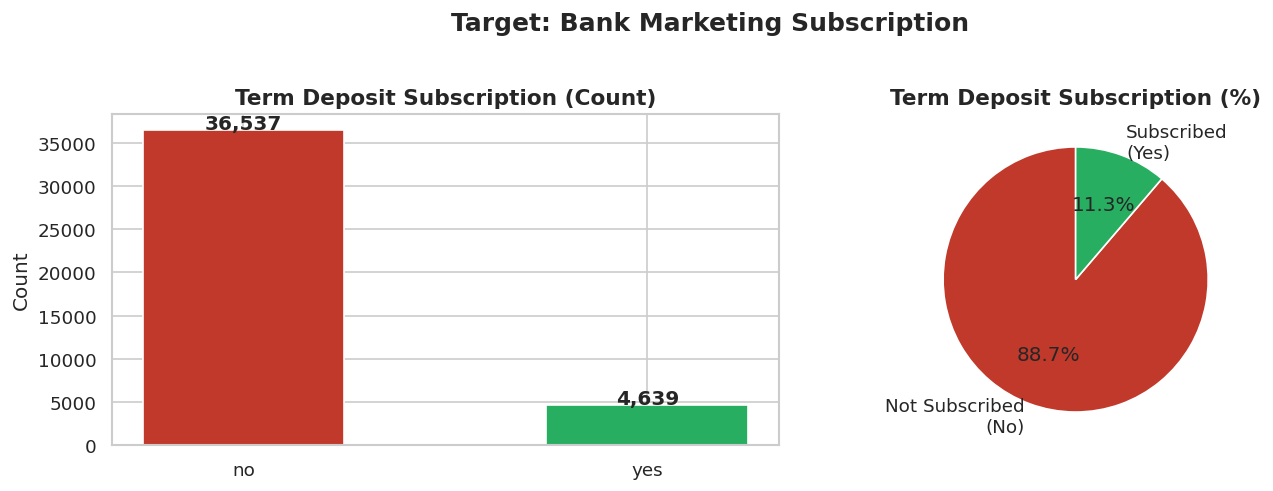

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

y_counts = df['y'].value_counts()
labels   = ['Not Subscribed\n(No)',
             'Subscribed\n(Yes)']

axes[0].bar(y_counts.index,
            y_counts.values,
            color=['#c0392b', '#27ae60'],
            edgecolor='white', width=0.5)
axes[0].set_title(
    'Term Deposit Subscription (Count)',
    fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(y_counts.values):
    axes[0].text(i, v + 100,
                 f'{v:,}',
                 ha='center',
                 fontweight='bold')

axes[1].pie(y_counts.values,
            labels=labels,
            autopct='%1.1f%%',
            colors=['#c0392b', '#27ae60'],
            startangle=90,
            wedgeprops={'edgecolor': 'white'})
axes[1].set_title(
    'Term Deposit Subscription (%)',
    fontsize=13, fontweight='bold')

plt.suptitle(
    'Target: Bank Marketing Subscription',
    fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('CB_01_target_dist.png',
            bbox_inches='tight')
plt.show()

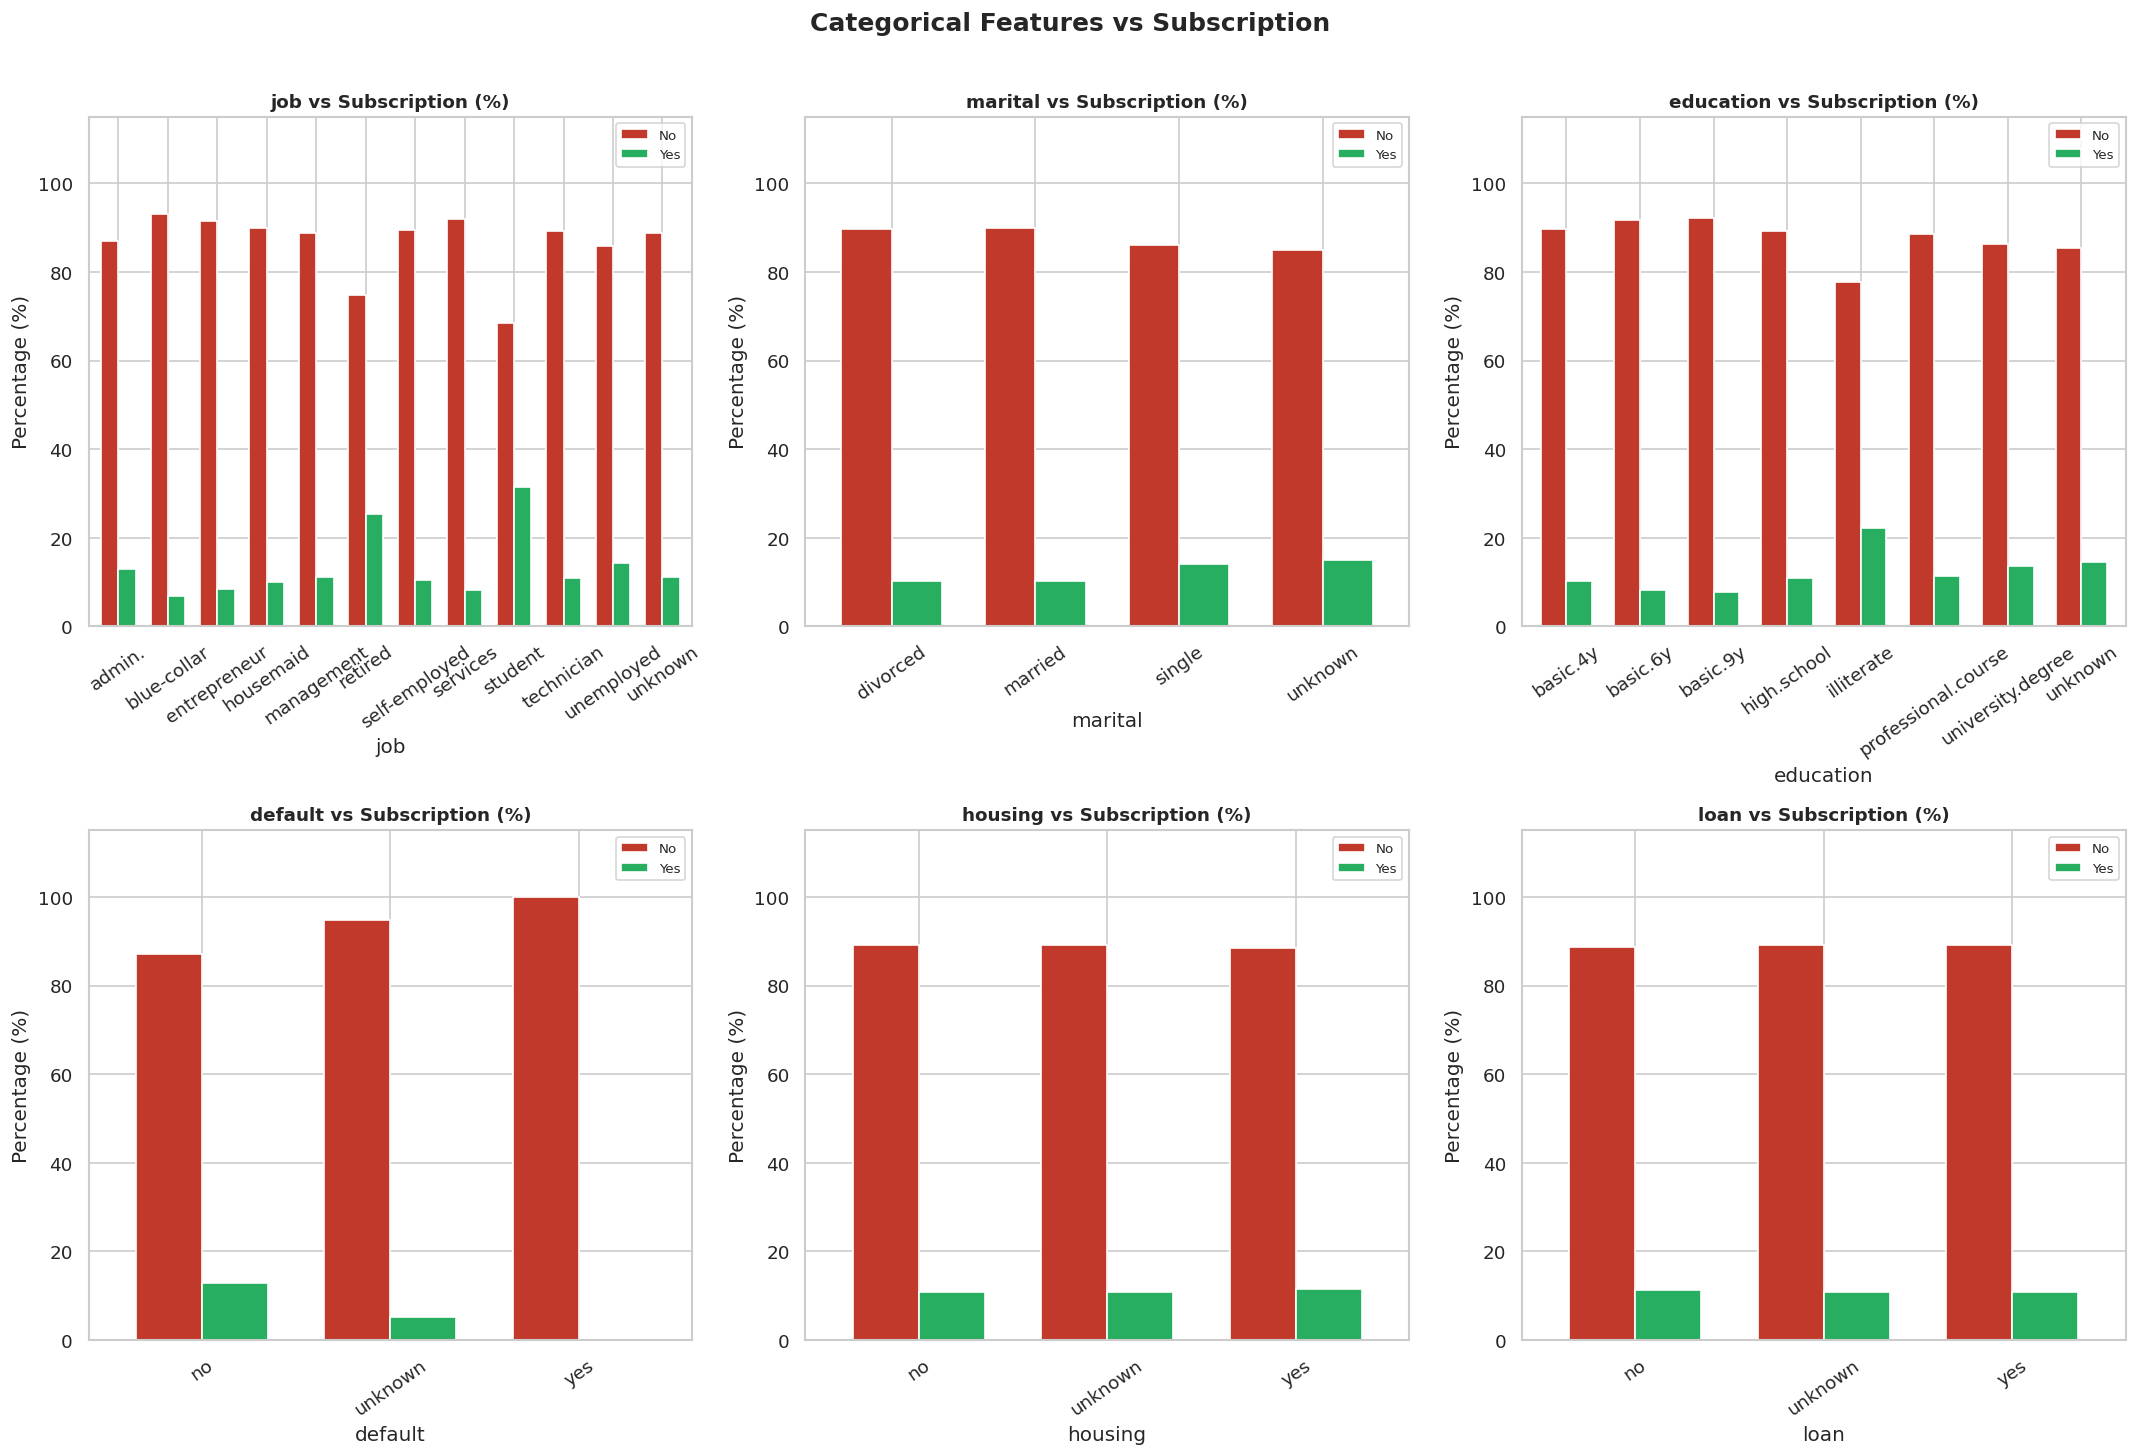

In [12]:
cat_plot_cols = [c for c in cat_cols
                 if c != 'y'][:6]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(cat_plot_cols):
    ct = pd.crosstab(
        df[col], df['y'],
        normalize='index') * 100
    if 'yes' in ct.columns:
        ct = ct[['no', 'yes']]
    ct.plot(kind='bar', ax=axes[i],
            color=['#c0392b', '#27ae60'],
            edgecolor='white', width=0.7)
    axes[i].set_title(
        f'{col} vs Subscription (%)',
        fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Percentage (%)')
    axes[i].tick_params(
        axis='x', rotation=35)
    axes[i].legend(
        ['No', 'Yes'], fontsize=8)
    axes[i].set_ylim(0, 115)

plt.suptitle(
    'Categorical Features vs Subscription',
    fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('CB_02_categorical_analysis.png',
            bbox_inches='tight')
plt.show()

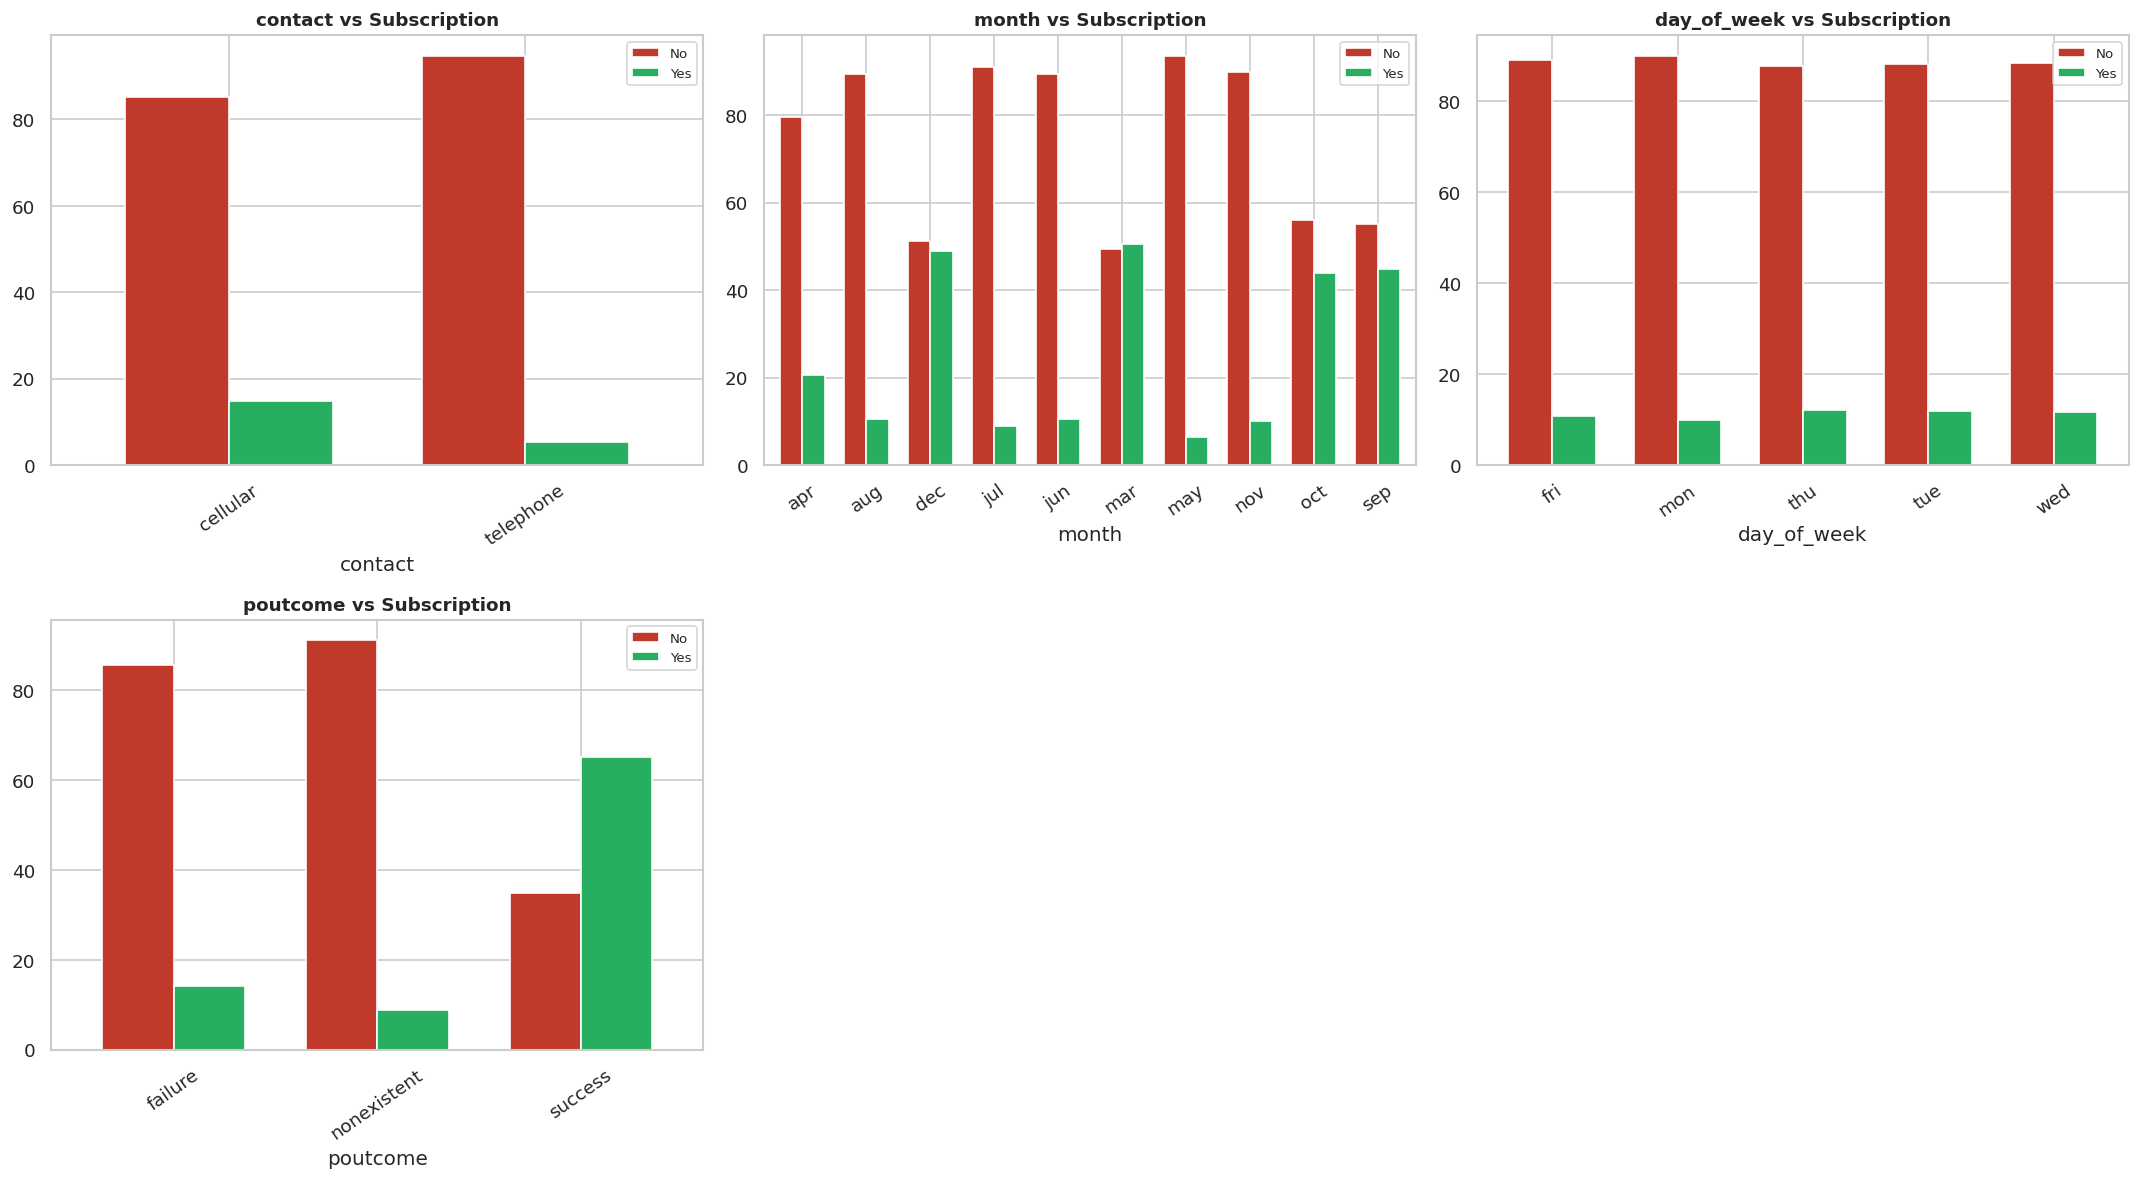

In [13]:
cat_plot_cols2 = [c for c in cat_cols
                  if c != 'y'][6:]

if cat_plot_cols2:
    n_cols = min(3, len(cat_plot_cols2))
    n_rows = (len(cat_plot_cols2) +
               n_cols - 1) // n_cols
    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(6*n_cols, 5*n_rows))
    axes = np.array(axes).flatten()

    for i, col in enumerate(cat_plot_cols2):
        ct = pd.crosstab(
            df[col], df['y'],
            normalize='index') * 100
        if 'yes' in ct.columns:
            ct = ct[['no', 'yes']]
        ct.plot(kind='bar', ax=axes[i],
                color=['#c0392b', '#27ae60'],
                edgecolor='white', width=0.7)
        axes[i].set_title(
            f'{col} vs Subscription',
            fontsize=11, fontweight='bold')
        axes[i].tick_params(
            axis='x', rotation=35)
        axes[i].legend(
            ['No', 'Yes'], fontsize=8)

    for j in range(len(cat_plot_cols2),
                   len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.savefig('CB_03_more_categoricals.png',
                bbox_inches='tight')
    plt.show()

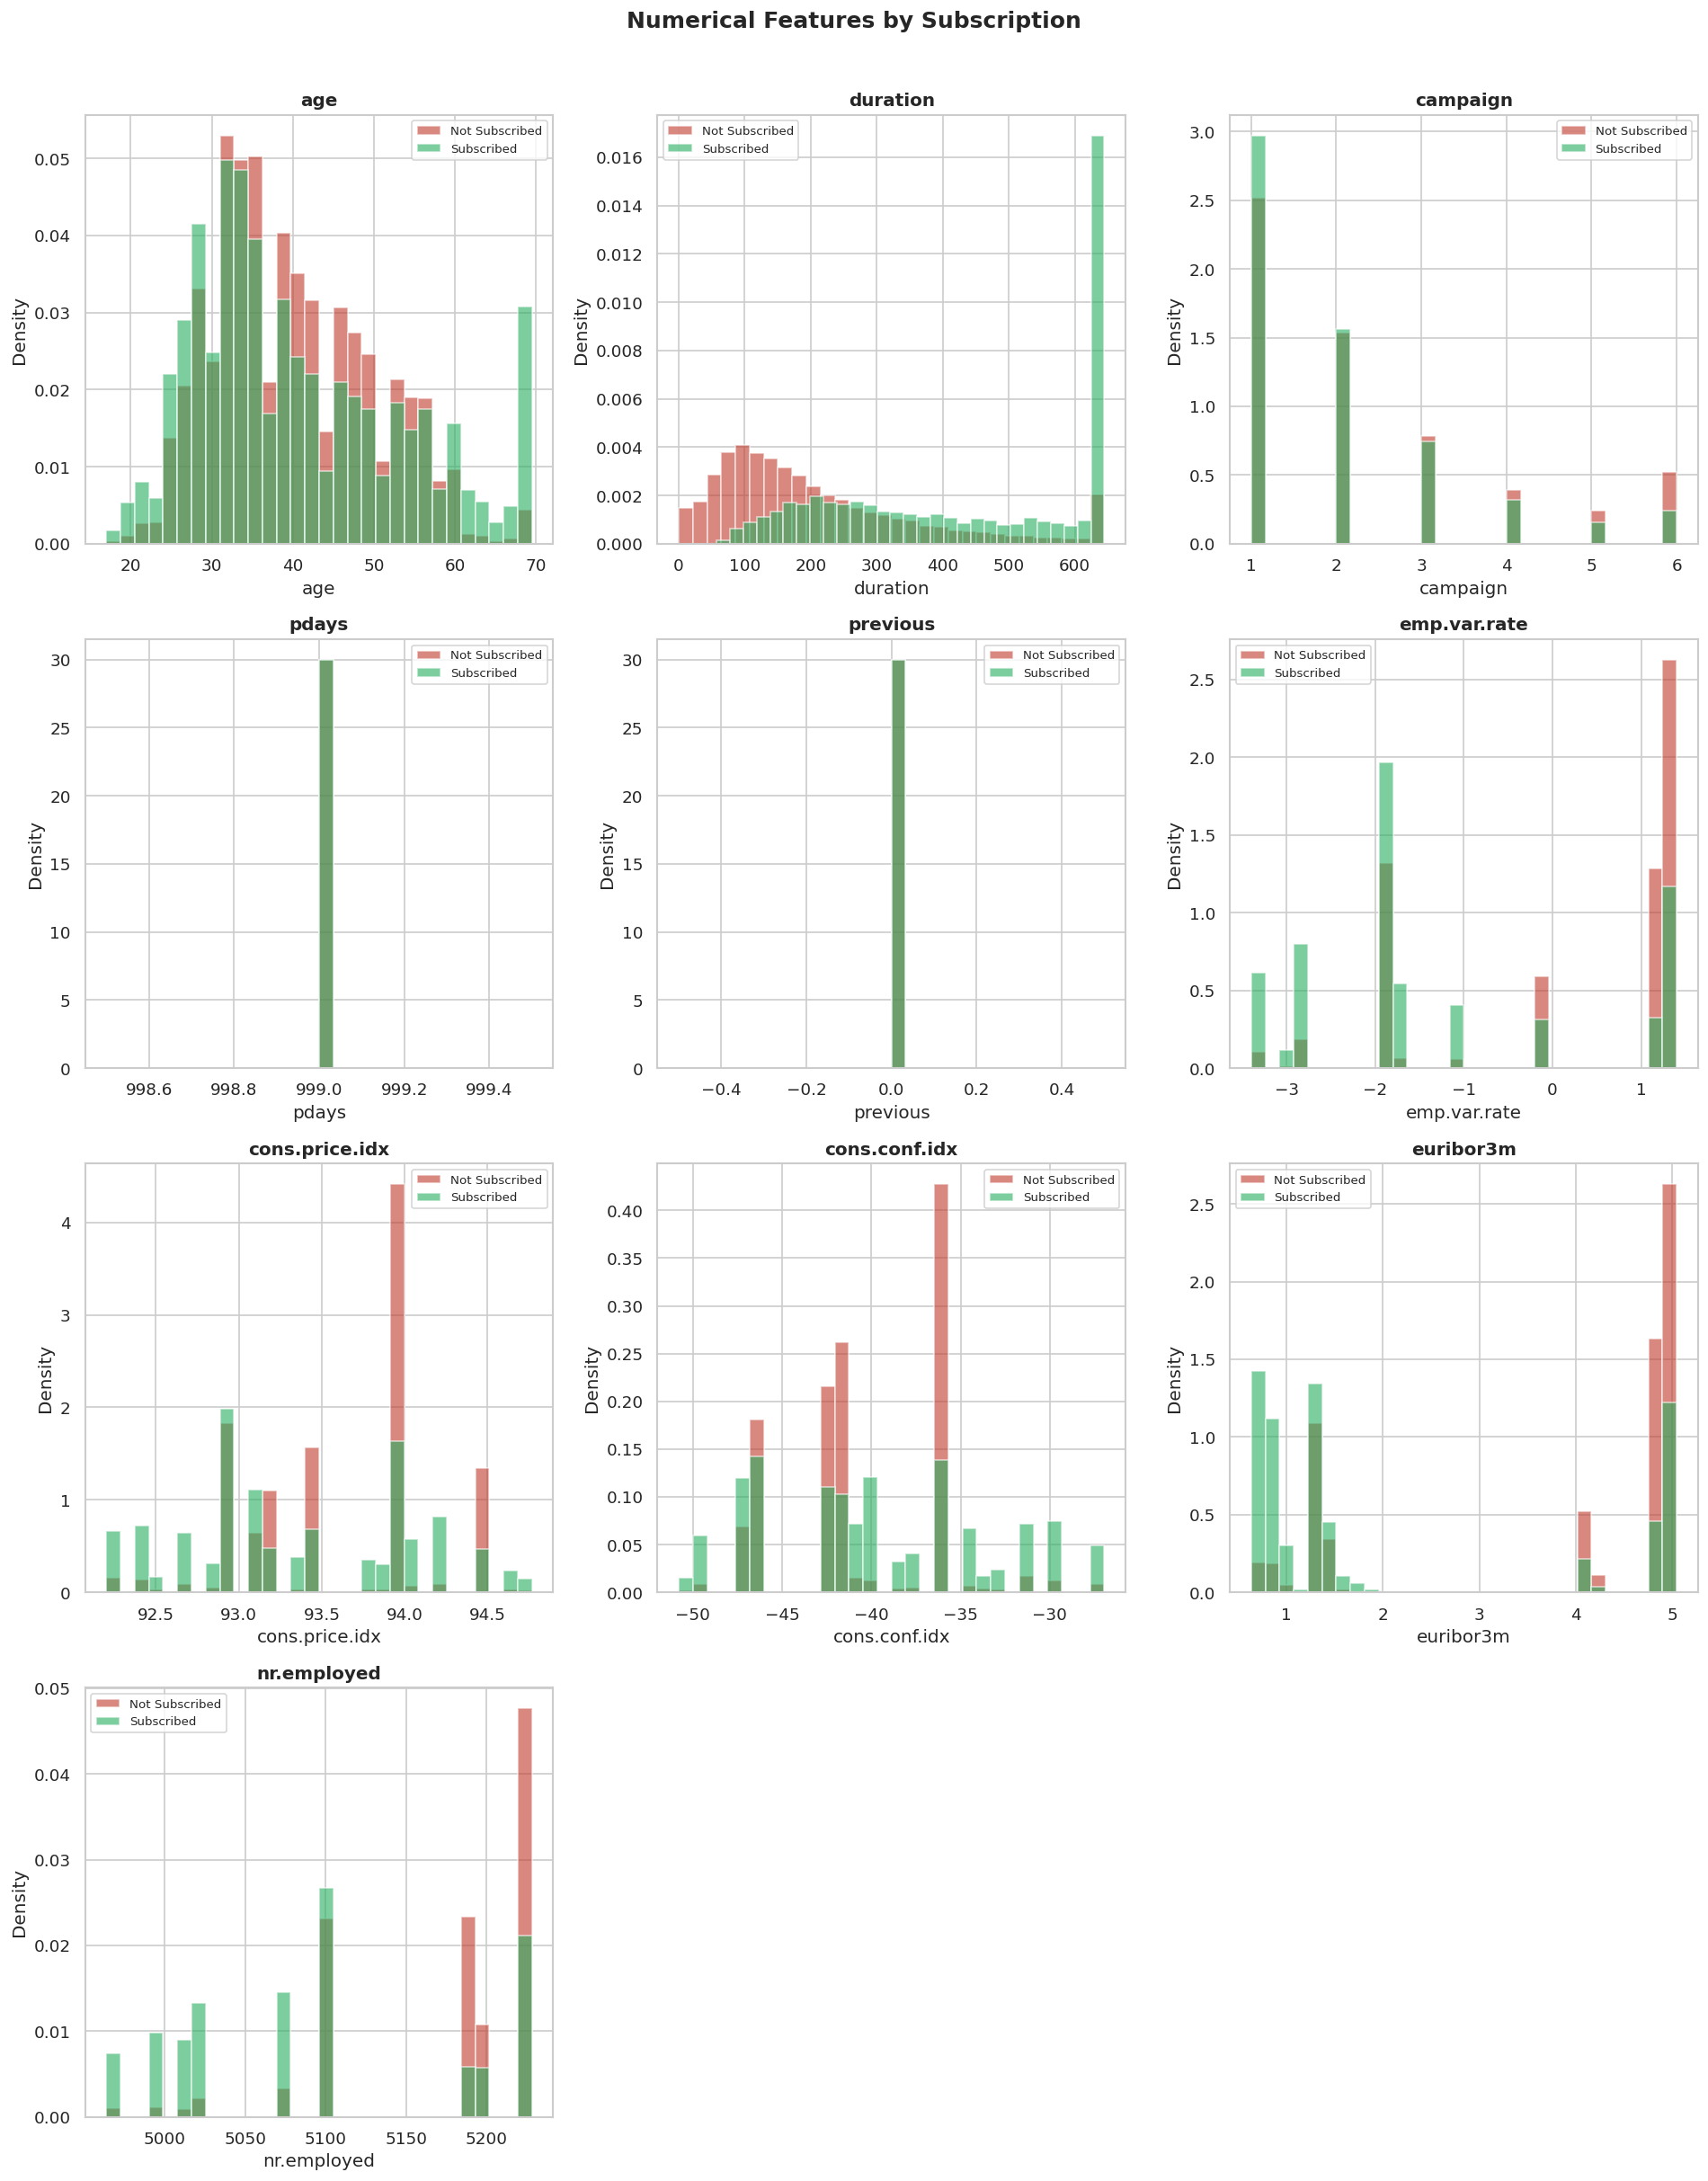

In [14]:
num_plot = [c for c in num_cols]

n_num   = len(num_plot)
n_c     = 3
n_r     = (n_num + n_c - 1) // n_c

fig, axes = plt.subplots(
    n_r, n_c,
    figsize=(16, 5*n_r))
axes = np.array(axes).flatten()

for i, col in enumerate(num_plot):
    for label, color, name in zip(
            ['no', 'yes'],
            ['#c0392b', '#27ae60'],
            ['Not Subscribed', 'Subscribed']):
        axes[i].hist(
            df[df['y']==label][col],
            bins=30, alpha=0.6,
            color=color, label=name,
            density=True)
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=8)

for j in range(n_num, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(
    'Numerical Features by Subscription',
    fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('CB_04_numerical_dist.png',
            bbox_inches='tight')
plt.show()

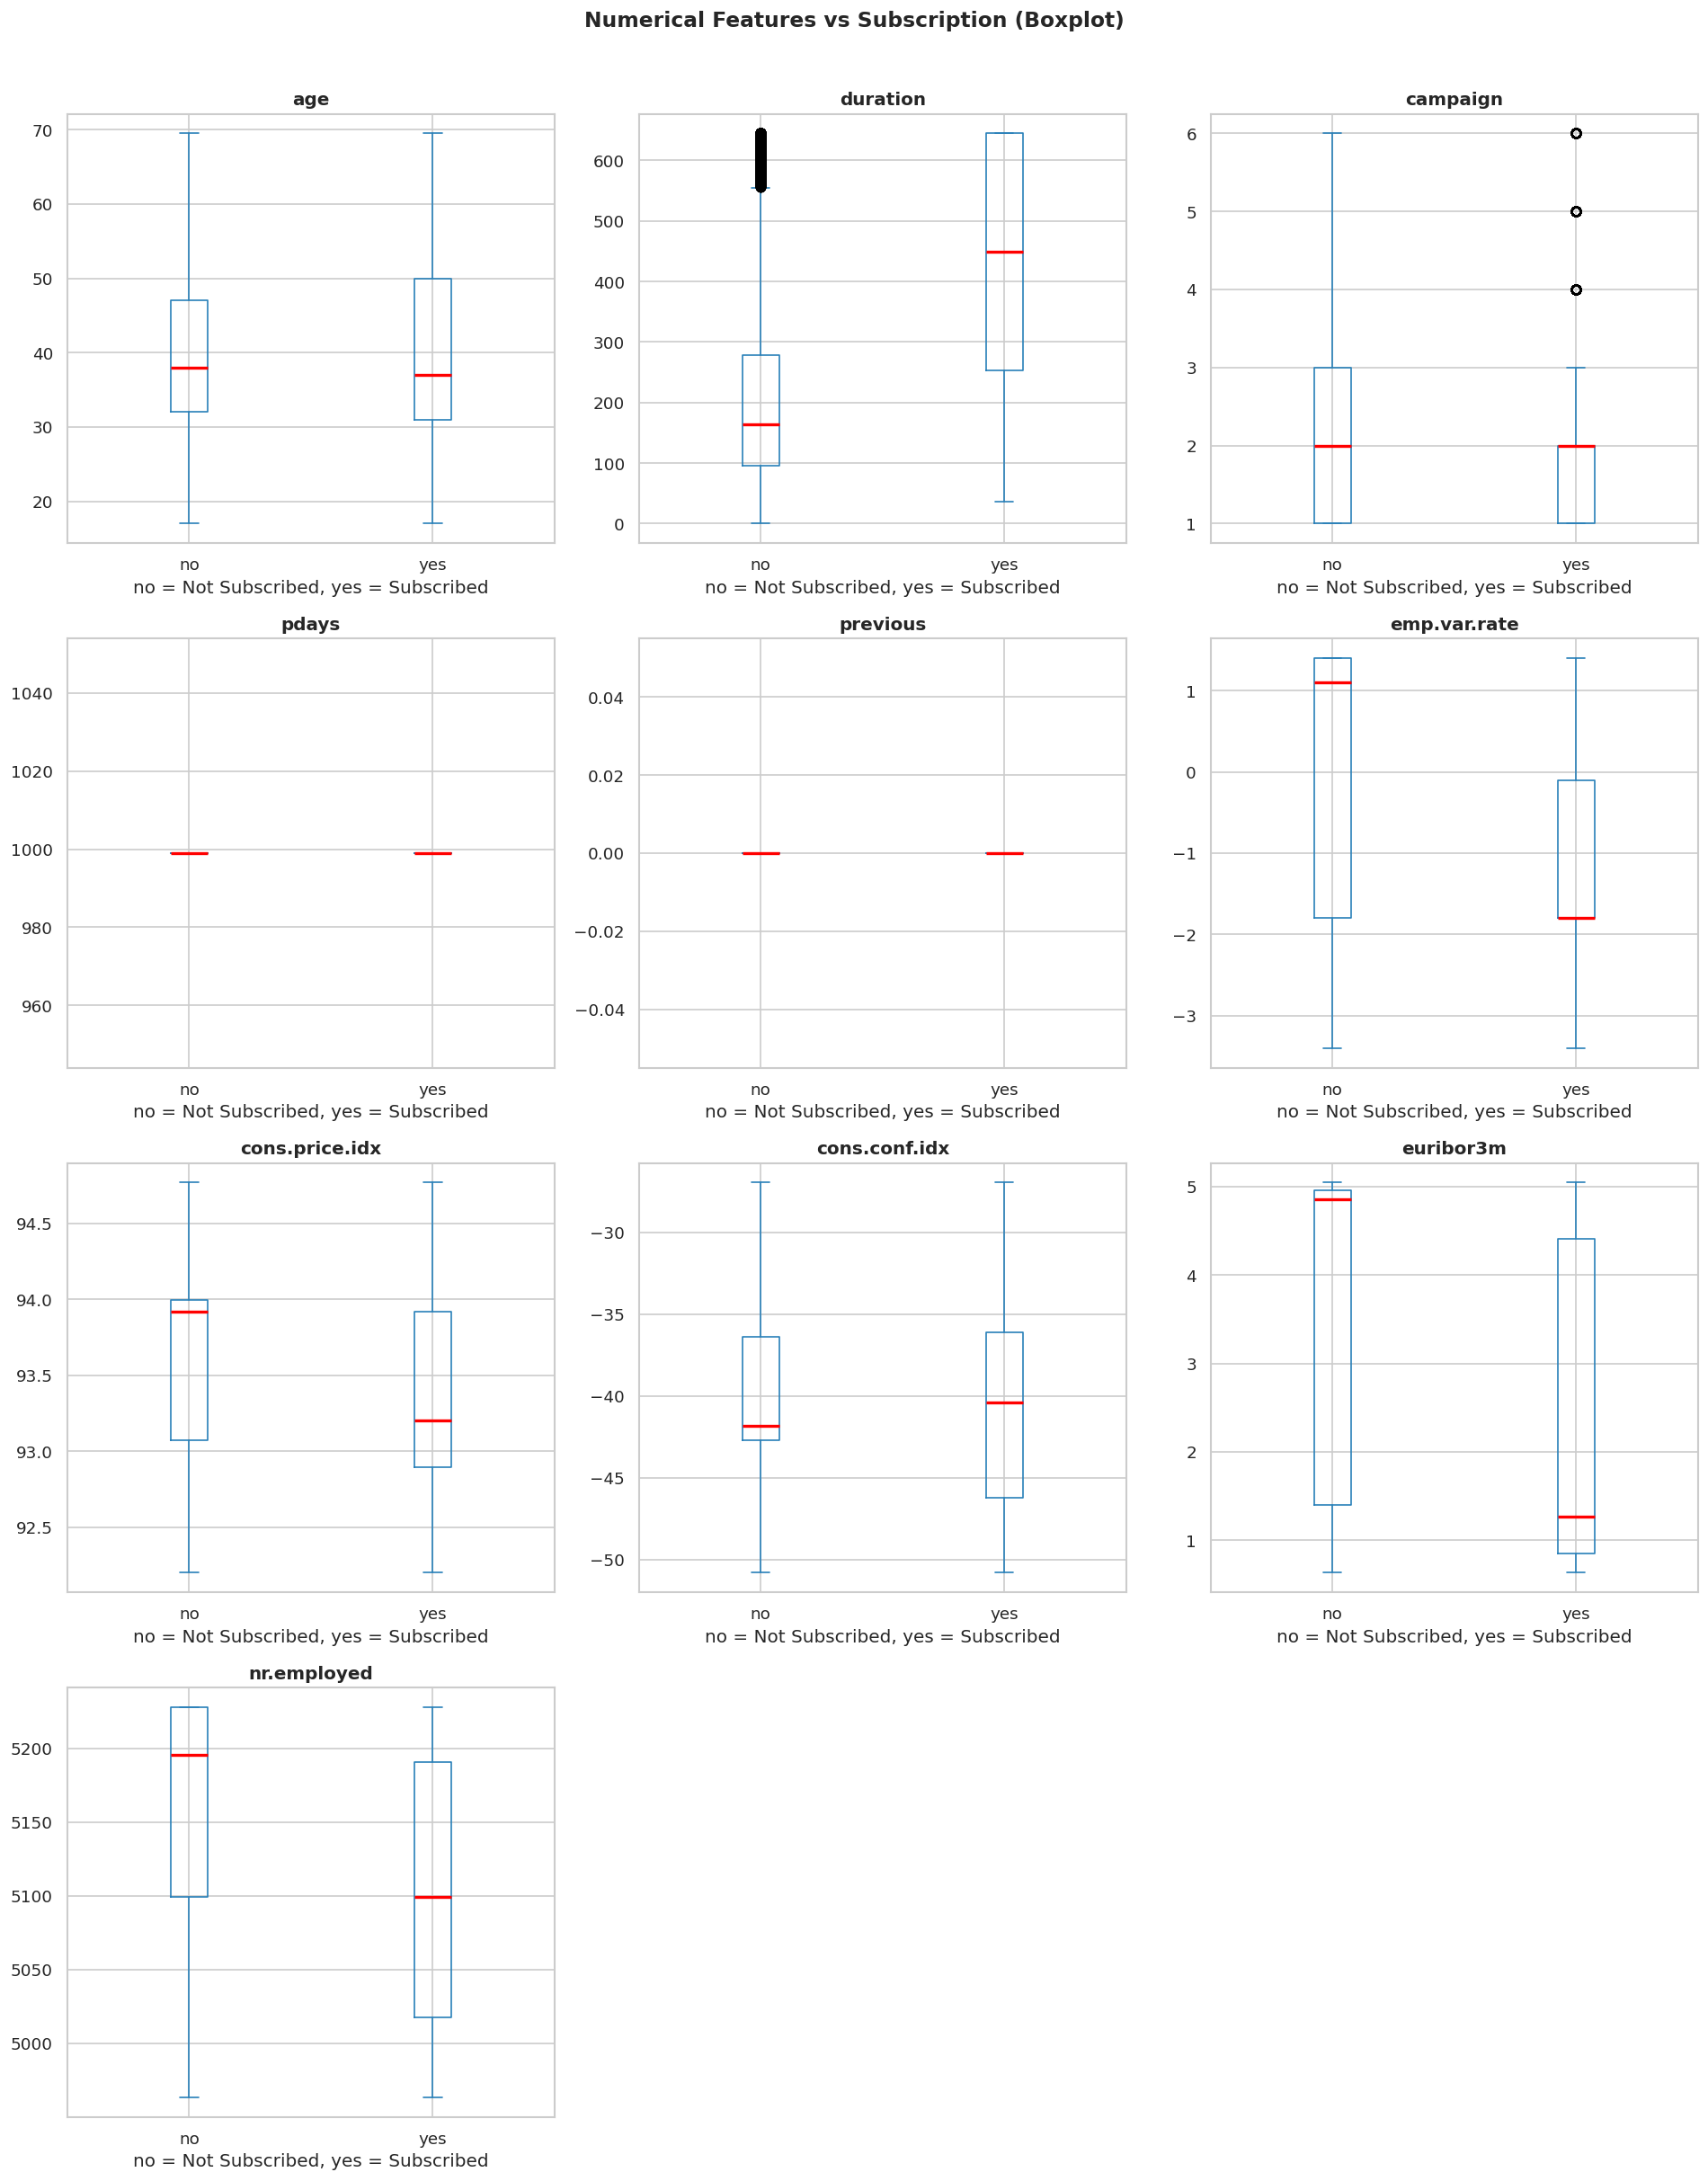

In [15]:
fig, axes = plt.subplots(
    n_r, n_c,
    figsize=(16, 5*n_r))
axes = np.array(axes).flatten()

for i, col in enumerate(num_plot):
    df.boxplot(
        column=col, by='y',
        ax=axes[i],
        boxprops=dict(color='#2980b9'),
        medianprops=dict(color='red',
                         linewidth=2),
        whiskerprops=dict(color='#2980b9'),
        capprops=dict(color='#2980b9'))
    axes[i].set_title(
        col, fontweight='bold')
    axes[i].set_xlabel(
        'no = Not Subscribed, '
        'yes = Subscribed')

for j in range(n_num, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(
    'Numerical Features vs Subscription '
    '(Boxplot)',
    fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('CB_05_numerical_boxplots.png',
            bbox_inches='tight')
plt.show()

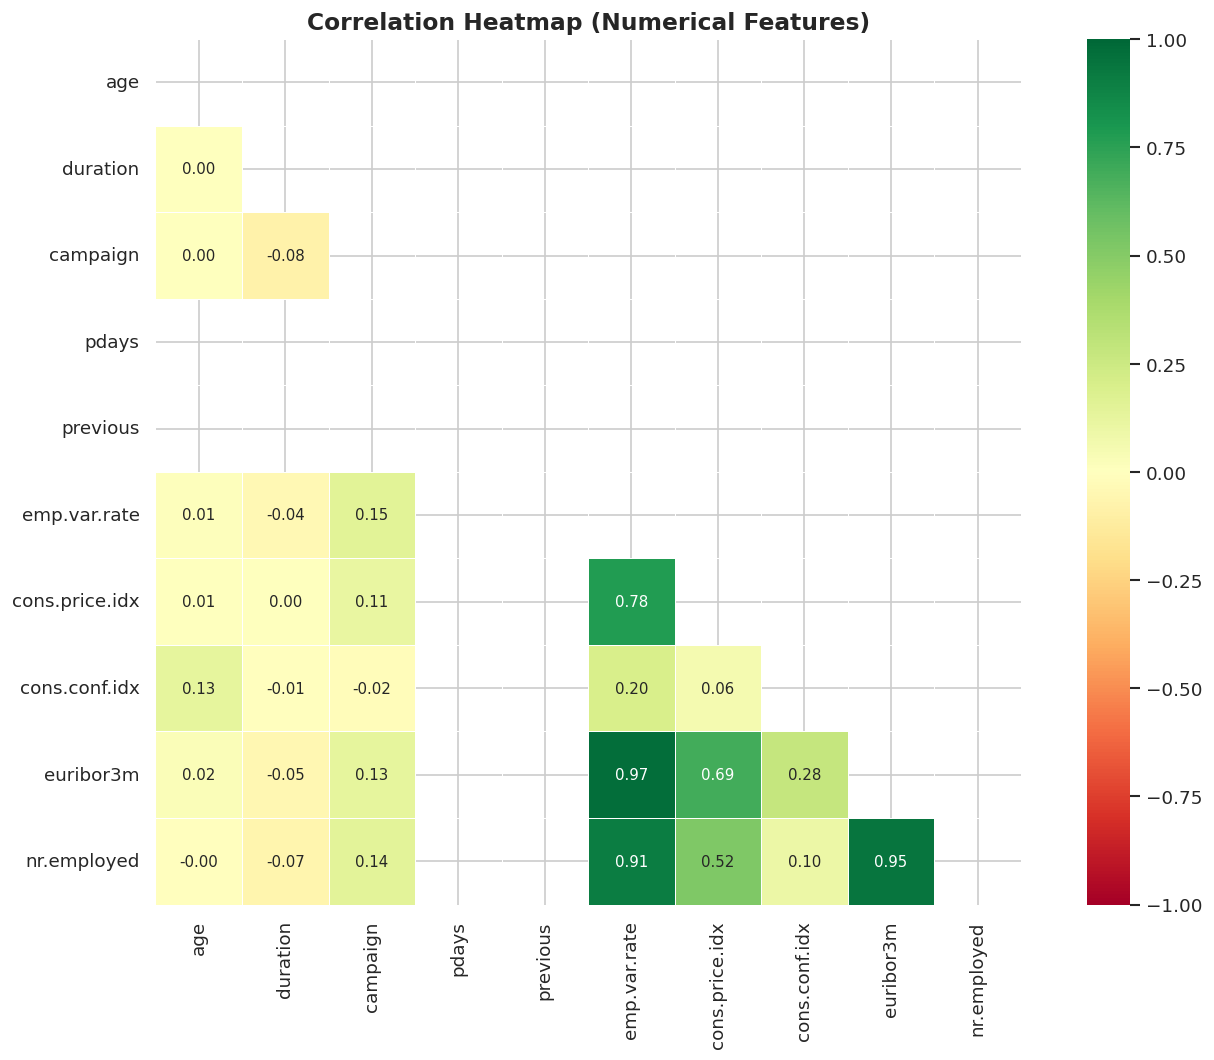

In [16]:
fig, ax = plt.subplots(figsize=(12, 9))

num_df  = df[num_cols].copy()
corr    = num_df.corr()
mask    = np.triu(np.ones_like(
    corr, dtype=bool))

sns.heatmap(corr, mask=mask,
            annot=True, fmt='.2f',
            cmap='RdYlGn',
            linewidths=0.4, ax=ax,
            annot_kws={'fontsize': 9},
            vmin=-1, vmax=1,
            center=0, square=True)
ax.set_title('Correlation Heatmap '
             '(Numerical Features)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('CB_06_correlation_heatmap.png',
            bbox_inches='tight')
plt.show()

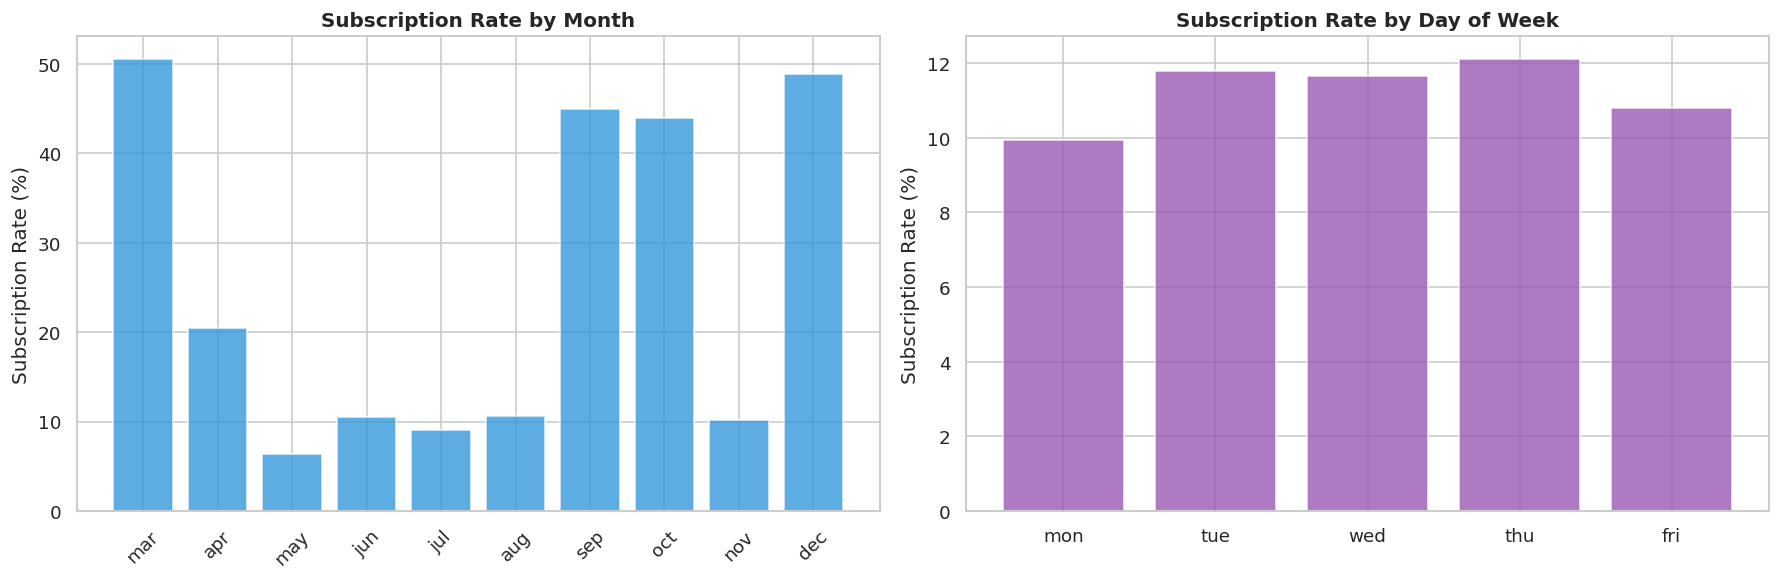

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Month subscription rate
if 'month' in df.columns:
    month_order = ['jan', 'feb', 'mar',
                   'apr', 'may', 'jun',
                   'jul', 'aug', 'sep',
                   'oct', 'nov', 'dec']
    month_order = [m for m in month_order
                   if m in df['month'].unique()]
    month_rate  = df.groupby('month')[
        'y'].apply(
        lambda x: (x=='yes').mean()*100
    ).reindex(month_order)

    axes[0].bar(range(len(month_rate)),
                month_rate.values,
                color='#3498db',
                edgecolor='white', alpha=0.8)
    axes[0].set_title(
        'Subscription Rate by Month',
        fontweight='bold', fontsize=12)
    axes[0].set_xticks(range(len(month_rate)))
    axes[0].set_xticklabels(
        month_rate.index, rotation=45)
    axes[0].set_ylabel('Subscription Rate (%)')

# Day of week
if 'day_of_week' in df.columns:
    dow_order  = ['mon', 'tue', 'wed',
                  'thu', 'fri']
    dow_order  = [d for d in dow_order
                  if d in df[
                      'day_of_week'].unique()]
    dow_rate   = df.groupby('day_of_week')[
        'y'].apply(
        lambda x: (x=='yes').mean()*100
    ).reindex(dow_order)

    axes[1].bar(range(len(dow_rate)),
                dow_rate.values,
                color='#9b59b6',
                edgecolor='white', alpha=0.8)
    axes[1].set_title(
        'Subscription Rate by Day of Week',
        fontweight='bold', fontsize=12)
    axes[1].set_xticks(range(len(dow_rate)))
    axes[1].set_xticklabels(
        dow_rate.index, rotation=0)
    axes[1].set_ylabel('Subscription Rate (%)')

plt.tight_layout()
plt.savefig('CB_07_time_analysis.png',
            bbox_inches='tight')
plt.show()

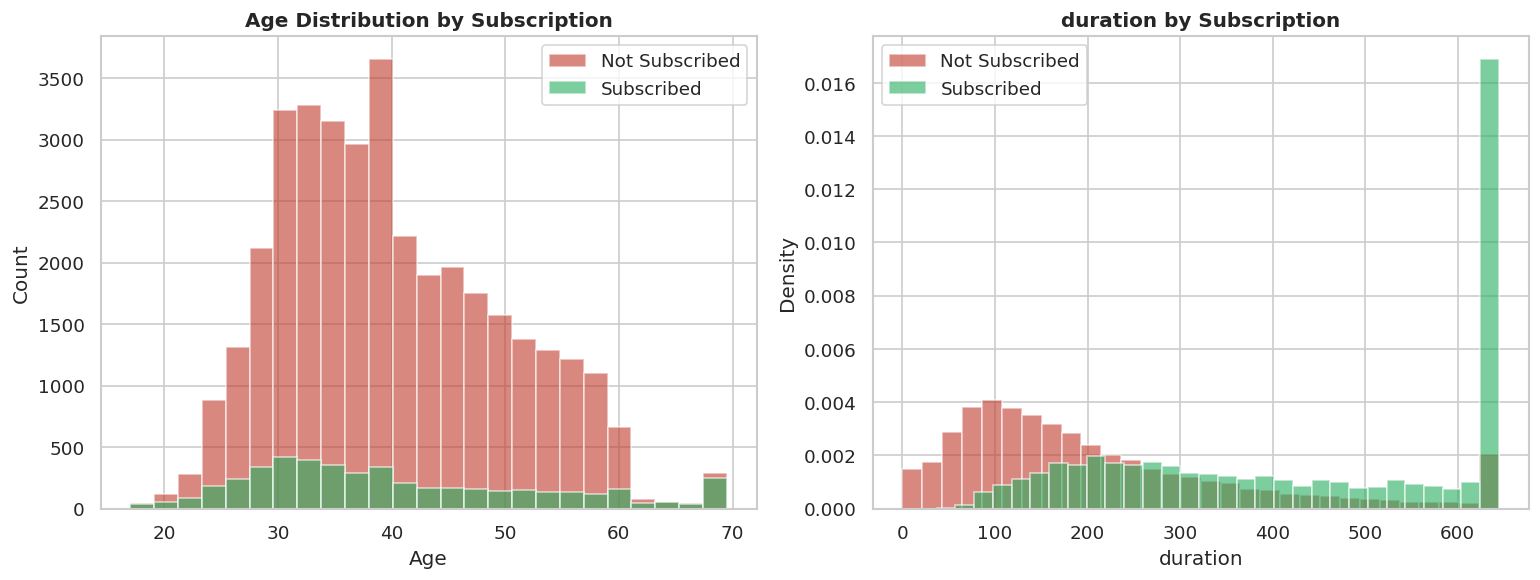

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Age by subscription
for label, color, name in zip(
        ['no', 'yes'],
        ['#c0392b', '#27ae60'],
        ['Not Subscribed', 'Subscribed']):
    if 'age' in df.columns:
        axes[0].hist(
            df[df['y']==label]['age'],
            bins=25, alpha=0.6,
            color=color, label=name)
axes[0].set_title(
    'Age Distribution by Subscription',
    fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].legend()

# Balance/Duration by subscription
dur_col = 'duration' if 'duration' in \
    df.columns else (
    'balance' if 'balance' in
    df.columns else num_cols[0])
for label, color, name in zip(
        ['no', 'yes'],
        ['#c0392b', '#27ae60'],
        ['Not Subscribed', 'Subscribed']):
    axes[1].hist(
        df[df['y']==label][dur_col],
        bins=30, alpha=0.6,
        color=color, label=name,
        density=True)
axes[1].set_title(
    f'{dur_col} by Subscription',
    fontweight='bold')
axes[1].set_xlabel(dur_col)
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.savefig('CB_08_age_analysis.png',
            bbox_inches='tight')
plt.show()

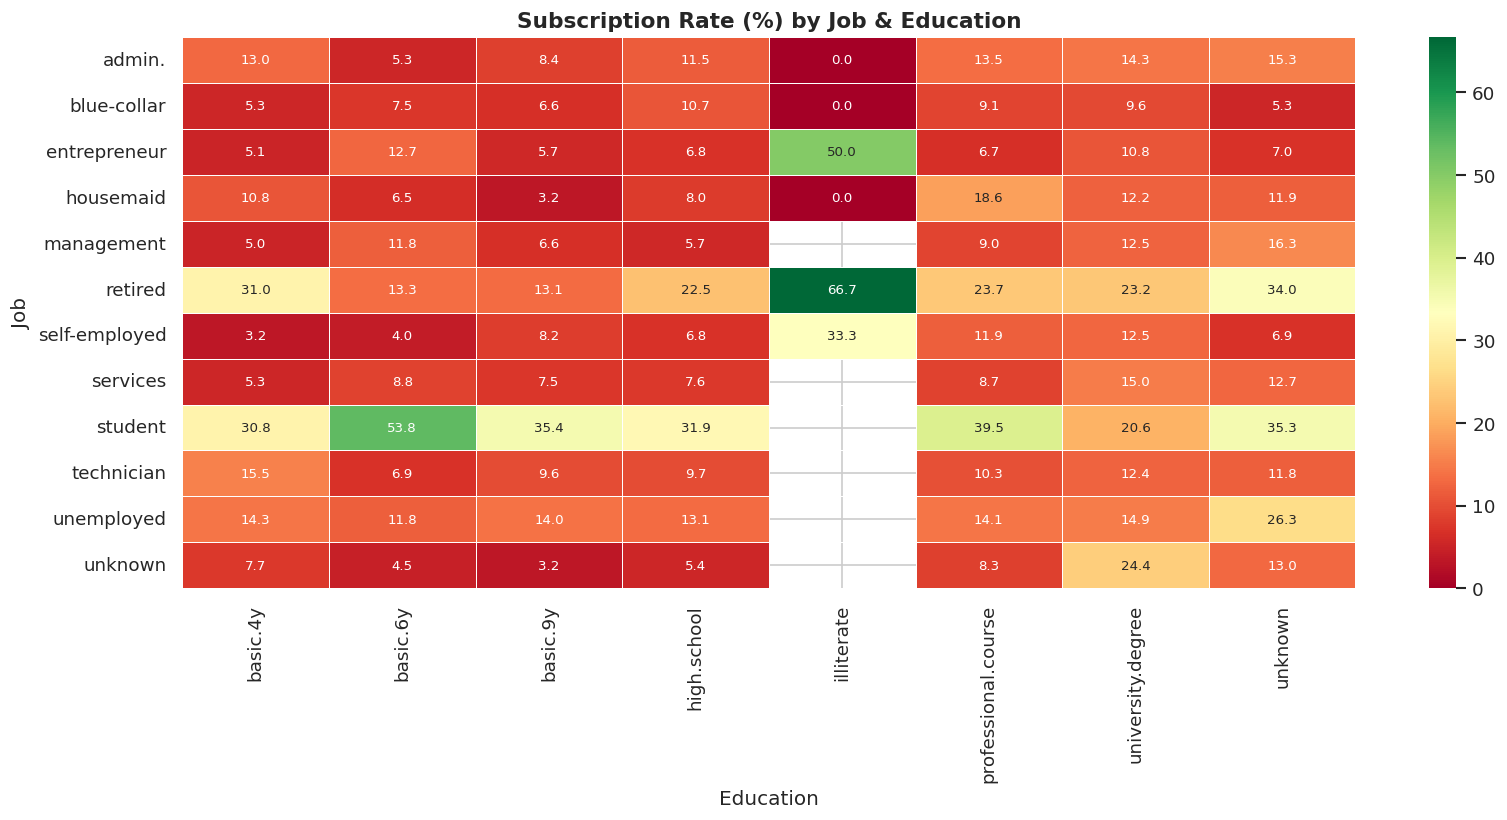

In [20]:
if ('job' in df.columns and
        'education' in df.columns):
    fig, ax = plt.subplots(figsize=(14, 7))

    job_edu = pd.crosstab(
        df['job'], df['education'],
        values=df['y'].map(
            {'yes': 1, 'no': 0}),
        aggfunc='mean') * 100

    sns.heatmap(job_edu,
                annot=True, fmt='.1f',
                cmap='RdYlGn',
                linewidths=0.4, ax=ax,
                annot_kws={'fontsize': 8})
    ax.set_title(
        'Subscription Rate (%) by '
        'Job & Education',
        fontsize=13, fontweight='bold')
    ax.set_xlabel('Education')
    ax.set_ylabel('Job')
    plt.tight_layout()
    plt.savefig('CB_09_job_edu_heatmap.png',
                bbox_inches='tight')
    plt.show()

In [21]:
df_model = df.copy()

# ── 6.1 Encode Target
df_model['y'] = df_model['y'].map(
    {'yes': 1, 'no': 0})
print("✅ Target encoded: yes→1, no→0")

# ── 6.2 Identify Categorical Features
# CatBoost handles categoricals NATIVELY
# No need for one-hot encoding!
cat_feature_cols = df_model.select_dtypes(
    include='object').columns.tolist()
print(f"\n🔤 Categorical features "
      f"({len(cat_feature_cols)}):")
for c in cat_feature_cols:
    print(f"   → {c}")

# Get categorical feature indices
cat_feature_indices = [
    df_model.columns.get_loc(c)
    for c in cat_feature_cols
    if c != 'y']
print(f"\n✅ CatBoost will handle these "
      f"natively — NO encoding needed!")

# ── 6.3 Handle remaining nulls
df_model[cat_feature_cols] = df_model[
    cat_feature_cols].fillna('unknown')
df_model.fillna(
    df_model.median(numeric_only=True),
    inplace=True)

print(f"\n📐 Shape: {df_model.shape}")
df_model.head(3)

✅ Target encoded: yes→1, no→0

🔤 Categorical features (10):
   → job
   → marital
   → education
   → default
   → housing
   → loan
   → contact
   → month
   → day_of_week
   → poutcome

✅ CatBoost will handle these natively — NO encoding needed!

📐 Shape: (41176, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56.0,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
1,57.0,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
2,37.0,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0


In [22]:
# Previous contact flag
if 'pdays' in df_model.columns:
    df_model['was_contacted_before'] = (
        df_model['pdays'] != 999
    ).astype(int)
    print("✅ 'was_contacted_before' created")

# High campaign flag
if 'campaign' in df_model.columns:
    camp_q3 = df_model['campaign'].quantile(0.75)
    df_model['high_campaign'] = (
        df_model['campaign'] > camp_q3
    ).astype(int)
    print("✅ 'high_campaign' created")

# Long call flag (if duration exists)
if 'duration' in df_model.columns:
    dur_med = df_model['duration'].median()
    df_model['long_call'] = (
        df_model['duration'] > dur_med
    ).astype(int)
    print("✅ 'long_call' created")

# Age group
if 'age' in df_model.columns:
    df_model['age_group'] = pd.cut(
        df_model['age'],
        bins=[0, 30, 40, 50, 60, 100],
        labels=['<30', '30-40', '40-50',
                '50-60', '60+'])
    df_model['age_group'] = df_model[
        'age_group'].astype(str)
    cat_feature_cols.append('age_group')
    print("✅ 'age_group' created")

# Economic indicators interaction
econ_cols = [c for c in [
    'emp.var.rate', 'cons.price.idx',
    'cons.conf.idx', 'euribor3m',
    'nr.employed']
    if c in df_model.columns]
if len(econ_cols) >= 2:
    df_model['econ_score'] = df_model[
        econ_cols].mean(axis=1)
    print("✅ 'econ_score' created")

# Previous outcome success flag
if 'poutcome' in df_model.columns:
    df_model['prev_success'] = (
        df_model['poutcome'] == 'success'
    ).astype(int)
    print("✅ 'prev_success' created")

print(f"\n📐 Final Shape: {df_model.shape}")

✅ 'was_contacted_before' created
✅ 'high_campaign' created
✅ 'long_call' created
✅ 'age_group' created
✅ 'econ_score' created
✅ 'prev_success' created

📐 Final Shape: (41176, 27)


In [23]:
X = df_model.drop(columns=['y'])
y = df_model['y']

print(f"🎯 Target distribution:")
print(f"   Not Subscribed (0): {(y==0).sum():,}")
print(f"   Subscribed (1)    : {(y==1).sum():,}")
print(f"   Subscription Rate : {y.mean()*100:.1f}%")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,
    random_state = 42,
    stratify     = y)

print(f"\n✅ Training set : {X_train.shape}")
print(f"✅ Test set     : {X_test.shape}")
print(f"✅ Features     : {X_train.shape[1]}")

# Update categorical indices for split data
cat_feature_cols_model = [
    c for c in cat_feature_cols
    if c in X.columns]
cat_feat_indices = [
    list(X.columns).index(c)
    for c in cat_feature_cols_model]

print(f"\n🔤 Categorical features in model: "
      f"{len(cat_feat_indices)}")
print(f"📌 CatBoost handles categoricals "
      f"NATIVELY — no encoding needed!")

# Class weight for imbalance
scale_pos_w = (y_train==0).sum() / (
    y_train==1).sum()
print(f"\n📌 Class weight ratio: "
      f"{scale_pos_w:.2f}")

🎯 Target distribution:
   Not Subscribed (0): 36,537
   Subscribed (1)    : 4,639
   Subscription Rate : 11.3%

✅ Training set : (32940, 26)
✅ Test set     : (8236, 26)
✅ Features     : 26

🔤 Categorical features in model: 11
📌 CatBoost handles categoricals NATIVELY — no encoding needed!

📌 Class weight ratio: 7.88


In [24]:
# CatBoost Pool — native data structure
train_pool = Pool(
    data              = X_train,
    label             = y_train,
    cat_features      = cat_feat_indices)

test_pool  = Pool(
    data              = X_test,
    label             = y_test,
    cat_features      = cat_feat_indices)

print("✅ Train Pool created!")
print("✅ Test Pool  created!")
print(f"   Cat features: {len(cat_feat_indices)}")
print(f"   Train size  : {len(X_train):,}")
print(f"   Test size   : {len(X_test):,}")

✅ Train Pool created!
✅ Test Pool  created!
   Cat features: 11
   Train size  : 32,940
   Test size   : 8,236


In [25]:
cb_baseline = CatBoostClassifier(
    iterations   = 200,
    learning_rate= 0.1,
    depth        = 6,
    cat_features = cat_feat_indices,
    auto_class_weights = 'Balanced',
    eval_metric  = 'AUC',
    random_seed  = 42,
    verbose      = 0)

cb_baseline.fit(
    train_pool,
    eval_set = test_pool)

y_pred_base = cb_baseline.predict(test_pool)
y_prob_base = cb_baseline.predict_proba(
    test_pool)[:, 1]

acc_base = accuracy_score(y_test, y_pred_base)
roc_base = roc_auc_score(y_test, y_prob_base)
apr_base = average_precision_score(
    y_test, y_prob_base)

print(f"  Accuracy      : {acc_base*100:.2f}%")
print(f"  ROC-AUC       : {roc_base:.4f}")
print(f"  Avg Precision : {apr_base:.4f}")
print("\n🔧 Now tuning with Native CV!")

  Accuracy      : 87.17%
  ROC-AUC       : 0.9520
  Avg Precision : 0.6638

🔧 Now tuning with Native CV!


In [27]:
cv_params = {
    'iterations'        : 500,
    'learning_rate'     : 0.05,
    'depth'             : 6,
    'loss_function'     : 'Logloss',
    'eval_metric'       : 'AUC',
    'auto_class_weights': 'Balanced',
    'random_seed'       : 42,
    'verbose'           : 0
}

cv_results = catboost_cv(
    params       = cv_params,
    pool         = train_pool,
    fold_count   = 5,
    stratified   = True,
    early_stopping_rounds = 30,
    verbose      = 50)

best_iter   = cv_results[
    'test-AUC-mean'].idxmax()
best_cv_auc = cv_results[
    'test-AUC-mean'].max()

print(f"\n✅ Best Iteration : {best_iter}")
print(f"✅ Best CV AUC    : {best_cv_auc:.4f}")
print(f"✅ CV Std         : "
      f"{cv_results['test-AUC-std'].iloc[best_iter]:.4f}")

Training on fold [0/5]
0:	test: 0.9022087	best: 0.9022087 (0)	total: 110ms	remaining: 55.1s
50:	test: 0.9427626	best: 0.9427626 (50)	total: 3.58s	remaining: 31.5s
100:	test: 0.9443034	best: 0.9443034 (100)	total: 6.36s	remaining: 25.1s
150:	test: 0.9451174	best: 0.9452055 (143)	total: 9.6s	remaining: 22.2s

bestTest = 0.9452331695
bestIteration = 167

Training on fold [1/5]
0:	test: 0.9112452	best: 0.9112452 (0)	total: 64.7ms	remaining: 32.3s
50:	test: 0.9434066	best: 0.9434066 (50)	total: 11.5s	remaining: 1m 41s
100:	test: 0.9444859	best: 0.9444948 (96)	total: 15.8s	remaining: 1m 2s
150:	test: 0.9451391	best: 0.9451444 (147)	total: 18.7s	remaining: 43.3s
200:	test: 0.9455241	best: 0.9455321 (198)	total: 22.6s	remaining: 33.6s
250:	test: 0.9461285	best: 0.9461359 (246)	total: 25.5s	remaining: 25.3s
300:	test: 0.9465555	best: 0.9465562 (297)	total: 28.4s	remaining: 18.8s
350:	test: 0.9469165	best: 0.9469227 (349)	total: 31.5s	remaining: 13.4s
400:	test: 0.9470465	best: 0.9471620 (383)	t

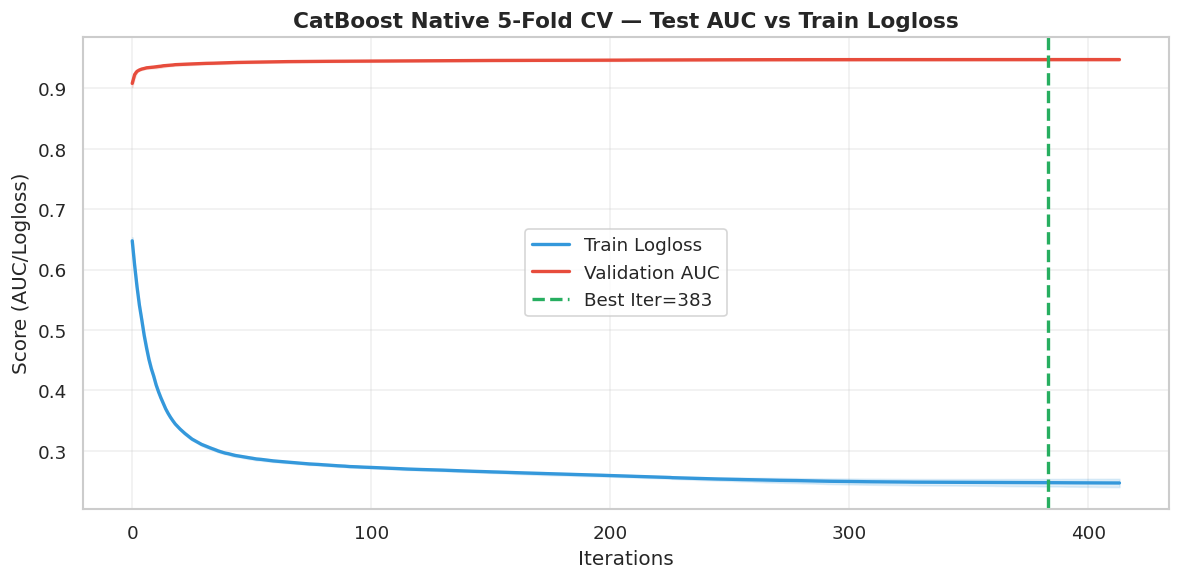

In [30]:
fig, ax = plt.subplots(figsize=(10, 5))

iters   = cv_results.index
tr_mean = cv_results['train-Logloss-mean'] # Changed to Logloss
tr_std  = cv_results['train-Logloss-std']  # Changed to Logloss
te_mean = cv_results['test-AUC-mean']
te_std  = cv_results['test-AUC-std']

ax.plot(iters, tr_mean,
        color='#3498db', lw=2,
        label='Train Logloss') # Changed label
ax.fill_between(iters,
                tr_mean - tr_std,
                tr_mean + tr_std,
                alpha=0.15, color='#3498db')
ax.plot(iters, te_mean,
        color='#e74c3c', lw=2,
        label='Validation AUC')
ax.fill_between(iters,
                te_mean - te_std,
                te_mean + te_std,
                alpha=0.15, color='#e74c3c')
ax.axvline(x=best_iter,
           color='#27ae60',
           linestyle='--', lw=2,
           label=f'Best Iter={best_iter}')
ax.set_title(
    'CatBoost Native 5-Fold CV — Test AUC vs Train Logloss', # Changed title
    fontsize=13, fontweight='bold')
ax.set_xlabel('Iterations')
ax.set_ylabel('Score (AUC/Logloss)') # Changed y-label
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('CB_10_native_cv.png',
            bbox_inches='tight')
plt.show()

In [34]:
param_dist = {
    'iterations'        : [200, 300],
    'learning_rate'     : [0.01, 0.05],
    'depth'             : [4, 5, 6],
    'l2_leaf_reg'       : [1, 3, 5],
    'border_count'      : [32, 64],
    'bagging_temperature': [0, 0.5],
    'random_strength'   : [0, 0.5],
    'min_data_in_leaf'  : [1, 3, 5]
}

rand_search = RandomizedSearchCV(
    estimator = CatBoostClassifier(
        # cat_features       = cat_feat_indices, # Removed from here
        auto_class_weights = 'Balanced',
        eval_metric        = 'AUC',
        random_seed        = 42,
        verbose            = 0),
    param_distributions = param_dist,
    n_iter       = 2,
    cv           = StratifiedKFold(2),
    scoring      = 'roc_auc',
    random_state = 42,
    n_jobs       = -1,
    verbose      = 1)

rand_search.fit(X_train, y_train, cat_features=cat_feat_indices) # Added cat_features as fit_params

print(f"\n✅ Best Params (Random): "
      f"{rand_search.best_params_}")
print(f"✅ Best CV ROC-AUC     : "
      f"{rand_search.best_score_:.4f}")

Fitting 2 folds for each of 2 candidates, totalling 4 fits

✅ Best Params (Random): {'random_strength': 0, 'min_data_in_leaf': 1, 'learning_rate': 0.05, 'l2_leaf_reg': 5, 'iterations': 200, 'depth': 5, 'border_count': 32, 'bagging_temperature': 0}
✅ Best CV ROC-AUC     : 0.9461


In [36]:
bp = rand_search.best_params_

param_grid = {
    'iterations': [
        bp['iterations']
    ],

    'learning_rate': [
        bp['learning_rate'],
        min(1.0, bp['learning_rate'] + 0.02)
    ],

    'depth': [
        bp['depth']
    ],

    'l2_leaf_reg': [
        bp['l2_leaf_reg']
    ],

    'border_count': [
        bp['border_count']
    ],

    'bagging_temperature': [
        bp['bagging_temperature']
    ],

    'random_strength': [
        bp['random_strength']
    ],

    'min_data_in_leaf': [
        bp['min_data_in_leaf']
    ]
}

grid_search = GridSearchCV(
    estimator = CatBoostClassifier(
        # cat_features       = cat_feat_indices, # Removed from here
        auto_class_weights = 'Balanced',
        eval_metric        = 'AUC',
        random_seed        = 42,
        verbose            = 0),
    param_grid   = param_grid,
    cv           = StratifiedKFold(5),
    scoring      = 'roc_auc',
    n_jobs       = -1,
    verbose      = 1)

grid_search.fit(X_train, y_train, cat_features=cat_feat_indices) # Added cat_features as fit_params

print(f"\n✅ Best Params (Grid): "
      f"{grid_search.best_params_}")
print(f"✅ Best CV ROC-AUC   : "
      f"{grid_search.best_score_:.4f}")

Fitting 5 folds for each of 2 candidates, totalling 10 fits

✅ Best Params (Grid): {'bagging_temperature': 0, 'border_count': 32, 'depth': 5, 'iterations': 200, 'l2_leaf_reg': 5, 'learning_rate': 0.07, 'min_data_in_leaf': 1, 'random_strength': 0}
✅ Best CV ROC-AUC   : 0.9478


In [39]:
from sklearn.base import clone

cb_best = CatBoostClassifier(
    **grid_search.best_params_,
    # cat_features       = cat_feat_indices, # Removed from here
    auto_class_weights = 'Balanced',
    eval_metric        = 'AUC',
    random_seed        = 42,
    verbose            = 0)

cb_best.fit(
    train_pool,
    eval_set          = test_pool,
    early_stopping_rounds = 30)

y_pred      = cb_best.predict(test_pool)
y_pred_prob = cb_best.predict_proba(
    test_pool)[:, 1]

acc = accuracy_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_pred_prob)
apr = average_precision_score(
    y_test, y_pred_prob)

# Manual cross-validation due to cross_val_score limitations
skf = StratifiedKFold(5)
cv_scores = []

for train_idx, val_idx in skf.split(X_train, y_train):
    X_train_fold, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_train_fold, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]

    cb_fold = clone(cb_best) # Clone the estimator without cat_features in constructor
    cb_fold.fit(X_train_fold, y_train_fold, cat_features=cat_feat_indices) # Pass cat_features to fit
    y_pred_proba_fold = cb_fold.predict_proba(X_val_fold)[:, 1]
    cv_scores.append(roc_auc_score(y_val_fold, y_pred_proba_fold))

cv = np.array(cv_scores)

print(f"\n{'Metric':<30} "
      f"{'Baseline':>10} {'Tuned':>10}")
print("-" * 52)
print(f"{'Accuracy':<30} "
      f"{acc_base*100:>9.2f}% "
      f"{acc*100:>9.2f}%")
print(f"{'ROC-AUC':<30} "
      f"{roc_base:>10.4f} {roc:>10.4f}")
print(f"{'Avg Precision':<30} "
      f"{apr_base:>10.4f} {apr:>10.4f}")
print(f"{'CV ROC-AUC (mean)':<30} "
      f"{'—':>10} {cv.mean():>10.4f}")
print(f"{'CV ROC-AUC (std)':<30} "
      f"{'—':>10} {cv.std():>10.4f}")

print(f"\n📋 Classification Report:\n")
print(classification_report(
    y_test, y_pred,
    target_names=['Not Subscribed',
                  'Subscribed']))


Metric                           Baseline      Tuned
----------------------------------------------------
Accuracy                           87.17%     86.63%
ROC-AUC                            0.9520     0.9516
Avg Precision                      0.6638     0.6651
CV ROC-AUC (mean)                       —     0.9478
CV ROC-AUC (std)                        —     0.0019

📋 Classification Report:

                precision    recall  f1-score   support

Not Subscribed       0.99      0.86      0.92      7308
    Subscribed       0.45      0.94      0.61       928

      accuracy                           0.87      8236
     macro avg       0.72      0.90      0.77      8236
  weighted avg       0.93      0.87      0.88      8236



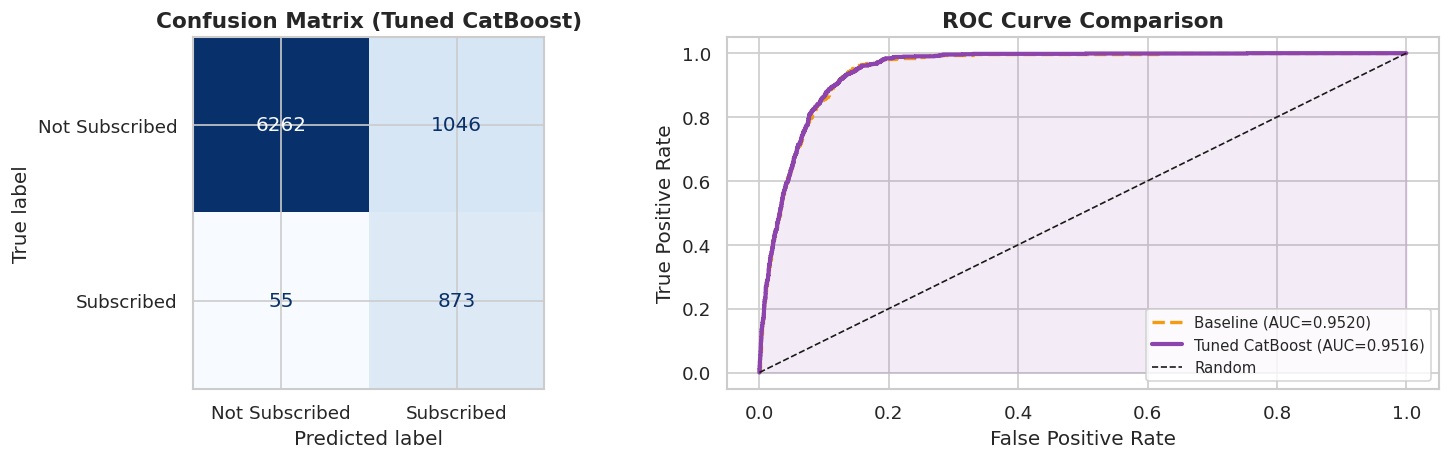

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix = cm,
    display_labels   = ['Not Subscribed',
                        'Subscribed'])
disp.plot(ax=axes[0], colorbar=False,
          cmap='Blues')
axes[0].set_title(
    'Confusion Matrix (Tuned CatBoost)',
    fontsize=13, fontweight='bold')

fpr_b, tpr_b, _ = roc_curve(
    y_test, y_prob_base)
fpr_t, tpr_t, _ = roc_curve(
    y_test, y_pred_prob)

axes[1].plot(fpr_b, tpr_b,
             color='#f39c12', lw=2,
             linestyle='--',
             label=f'Baseline '
                   f'(AUC={roc_base:.4f})')
axes[1].plot(fpr_t, tpr_t,
             color='#8e44ad', lw=2.5,
             label=f'Tuned CatBoost '
                   f'(AUC={roc:.4f})')
axes[1].fill_between(fpr_t, tpr_t,
                     alpha=0.1,
                     color='#8e44ad')
axes[1].plot([0,1],[0,1], 'k--',
             lw=1, label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve Comparison',
                  fontsize=13,
                  fontweight='bold')
axes[1].legend(loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('CB_11_confusion_roc.png',
            bbox_inches='tight')
plt.show()

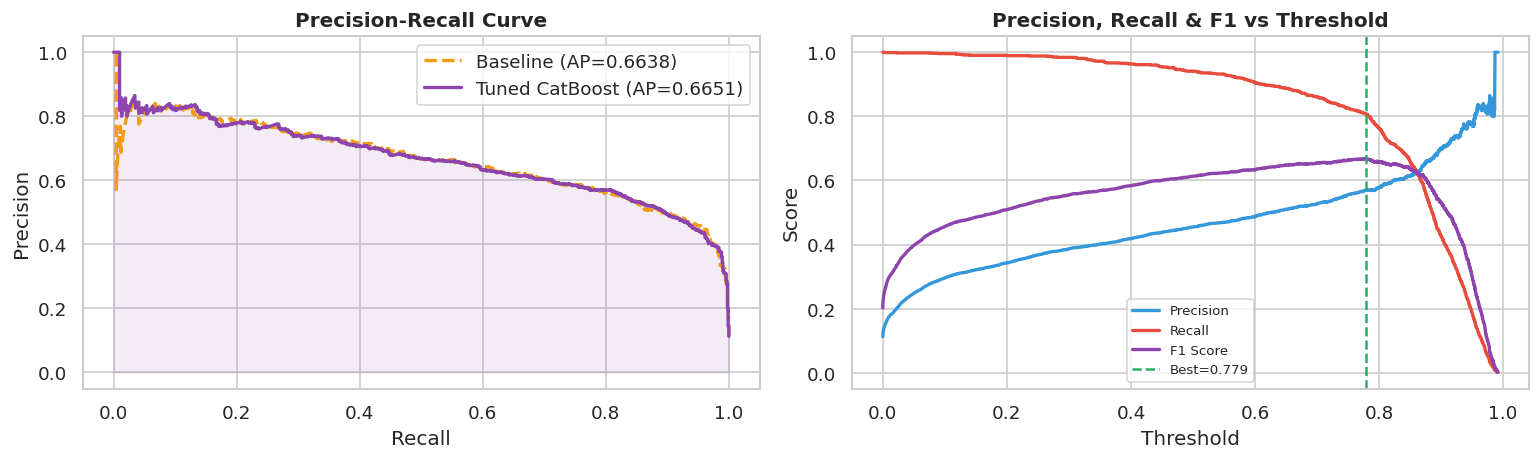

In [41]:
precision, recall, thresholds = \
    precision_recall_curve(
        y_test, y_pred_prob)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

pr_b, rc_b, _ = precision_recall_curve(
    y_test, y_prob_base)
axes[0].plot(rc_b, pr_b,
             color='#f39c12', lw=2,
             linestyle='--',
             label=f'Baseline '
                   f'(AP={apr_base:.4f})')
axes[0].plot(recall, precision,
             color='#8e44ad', lw=2,
             label=f'Tuned CatBoost '
                   f'(AP={apr:.4f})')
axes[0].fill_between(recall, precision,
                     alpha=0.1,
                     color='#8e44ad')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve',
                  fontsize=12,
                  fontweight='bold')
axes[0].legend()

f1 = (2 * precision[:-1] * recall[:-1] /
      (precision[:-1] + recall[:-1] + 1e-8))
best_thresh = thresholds[np.argmax(f1)]

axes[1].plot(thresholds, precision[:-1],
             color='#3498db', lw=2,
             label='Precision')
axes[1].plot(thresholds, recall[:-1],
             color='#e74c3c', lw=2,
             label='Recall')
axes[1].plot(thresholds, f1,
             color='#8e44ad', lw=2,
             label='F1 Score')
axes[1].axvline(x=best_thresh,
                color='#27ae60',
                linestyle='--',
                label=f'Best='
                      f'{best_thresh:.3f}')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Score')
axes[1].set_title(
    'Precision, Recall & F1 vs Threshold',
    fontsize=12, fontweight='bold')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('CB_12_precision_recall.png',
            bbox_inches='tight')
plt.show()

⏳ Calculating Permutation Importance...


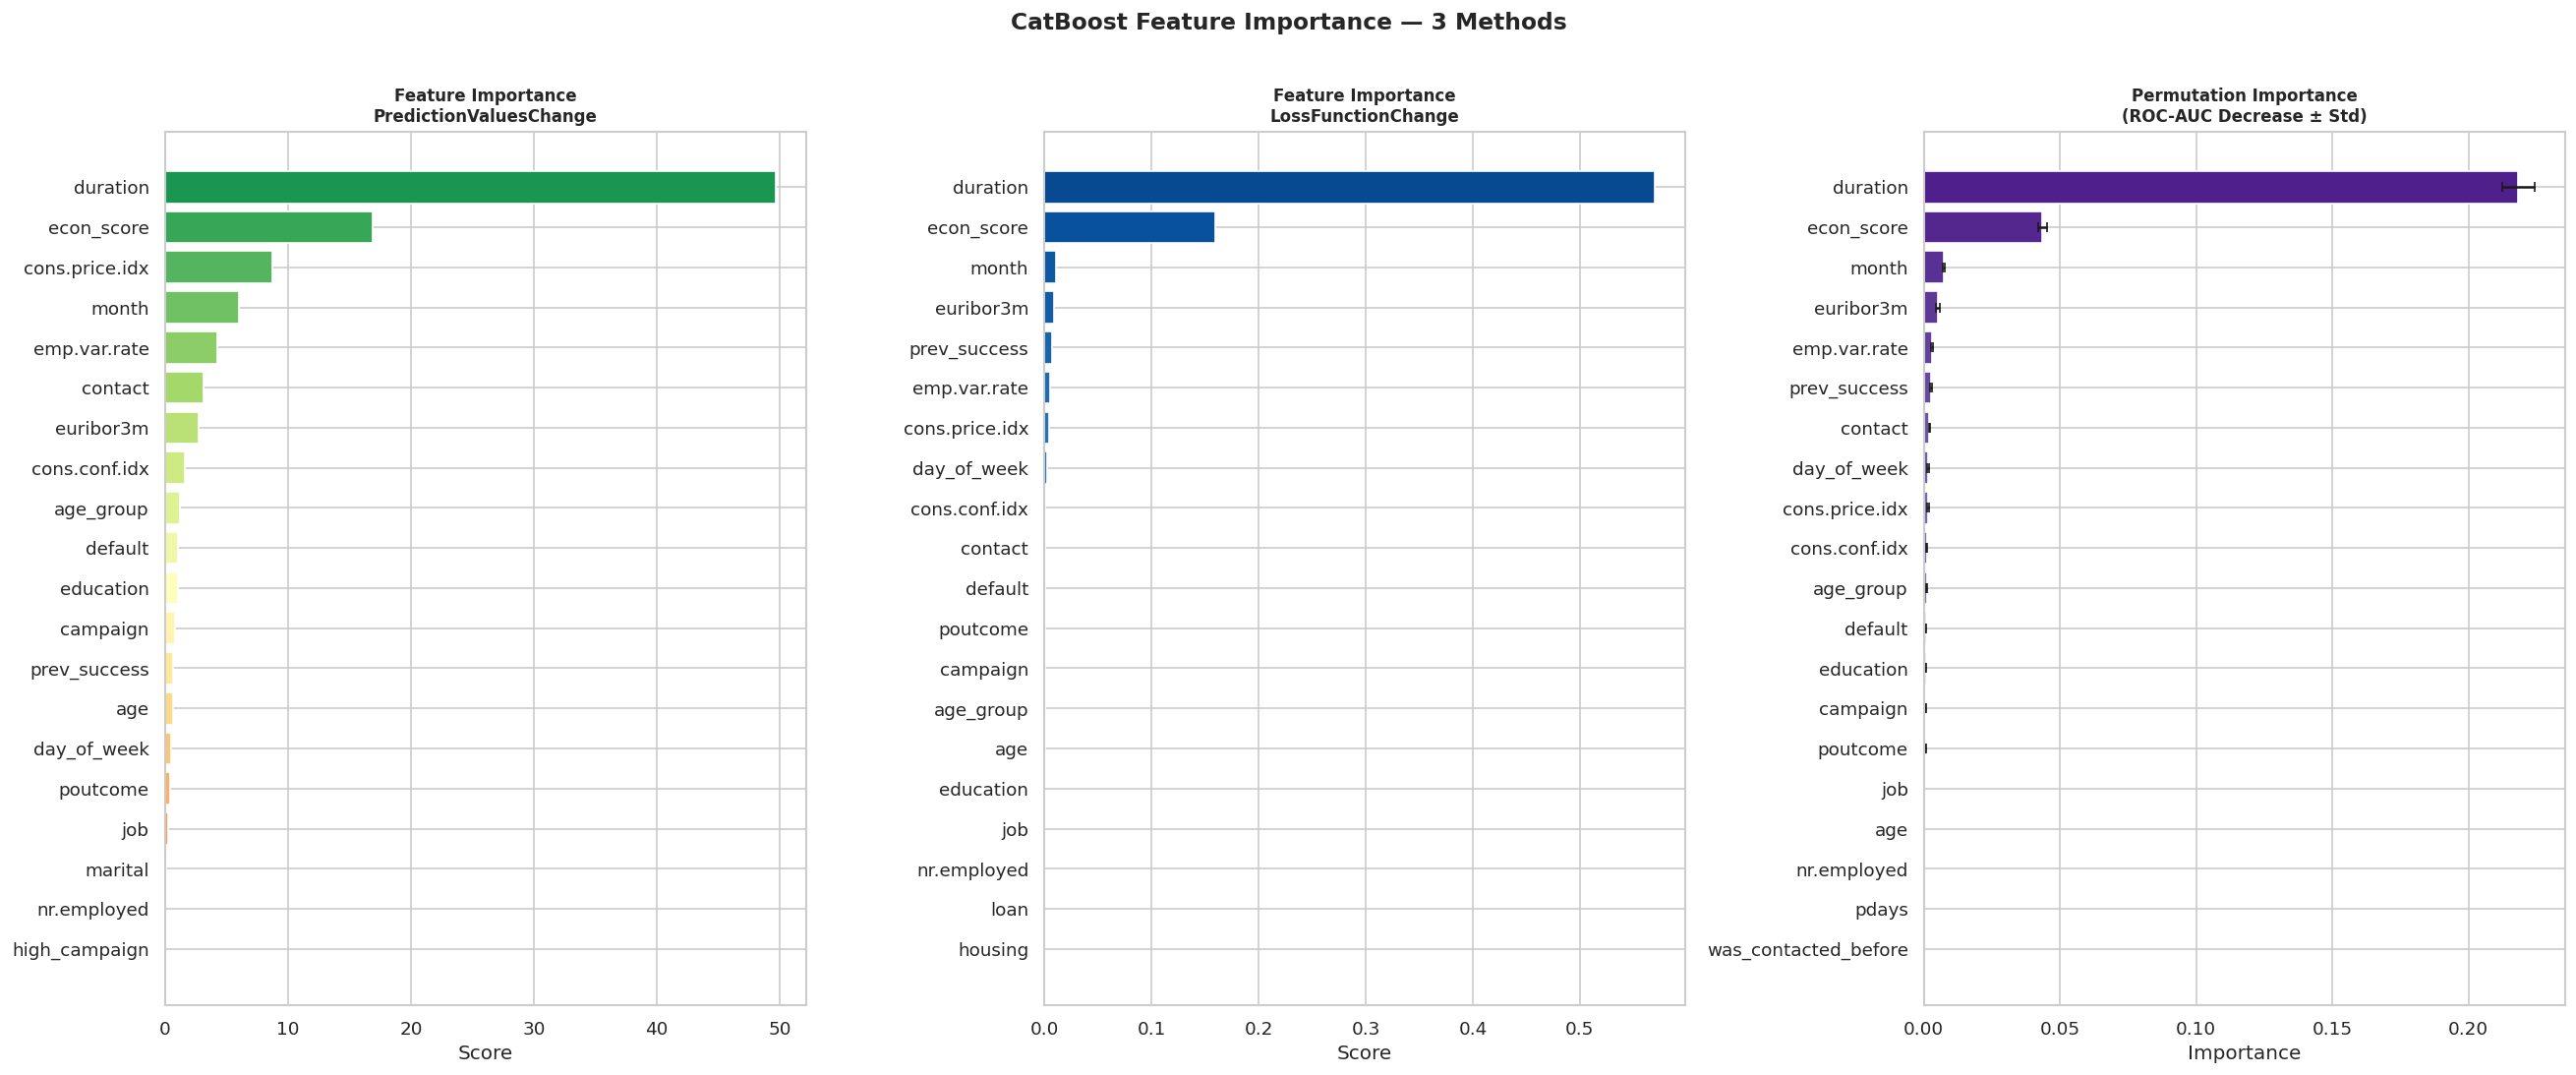

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(22, 9))

feature_names = list(X.columns)

# PredictionValuesChange
imp_pred = cb_best.get_feature_importance(
    type='PredictionValuesChange')
fi_pred = pd.DataFrame({
    'Feature'   : feature_names,
    'Importance': imp_pred
}).sort_values('Importance',
               ascending=False).head(20)

colors1 = plt.cm.RdYlGn(
    np.linspace(0.15, 0.9,
                len(fi_pred)))[::-1]
axes[0].barh(fi_pred['Feature'],
             fi_pred['Importance'],
             color=colors1, edgecolor='white')
axes[0].set_title(
    'Feature Importance\n'
    'PredictionValuesChange',
    fontweight='bold', fontsize=10)
axes[0].set_xlabel('Score')
axes[0].invert_yaxis()

# LossFunctionChange
imp_loss = cb_best.get_feature_importance(
    data=test_pool,
    type='LossFunctionChange')
fi_loss = pd.DataFrame({
    'Feature'   : feature_names,
    'Importance': imp_loss
}).sort_values('Importance',
               ascending=False).head(20)

colors2 = plt.cm.Blues(
    np.linspace(0.4, 0.9,
                len(fi_loss)))[::-1]
axes[1].barh(fi_loss['Feature'],
             fi_loss['Importance'],
             color=colors2, edgecolor='white')
axes[1].set_title(
    'Feature Importance\n'
    'LossFunctionChange',
    fontweight='bold', fontsize=10)
axes[1].set_xlabel('Score')
axes[1].invert_yaxis()

# Permutation Importance
print("⏳ Calculating Permutation Importance...")
perm_imp = permutation_importance(
    cb_best, X_test, y_test,
    n_repeats    = 8,
    random_state = 42,
    scoring      = 'roc_auc',
    n_jobs       = -1)

perm_df = pd.DataFrame({
    'Feature'   : feature_names,
    'Importance': perm_imp.importances_mean,
    'Std'       : perm_imp.importances_std
}).sort_values('Importance',
               ascending=False).head(20)

colors3 = plt.cm.Purples(
    np.linspace(0.4, 0.9,
                len(perm_df)))[::-1]
axes[2].barh(perm_df['Feature'],
             perm_df['Importance'],
             xerr=perm_df['Std'],
             color=colors3,
             edgecolor='white', capsize=3)
axes[2].set_title(
    'Permutation Importance\n'
    '(ROC-AUC Decrease ± Std)',
    fontweight='bold', fontsize=10)
axes[2].set_xlabel('Importance')
axes[2].axvline(x=0, color='red',
                linestyle='--', lw=1)
axes[2].invert_yaxis()

plt.suptitle(
    'CatBoost Feature Importance — 3 Methods',
    fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('CB_13_feature_importance.png',
            bbox_inches='tight')
plt.show()

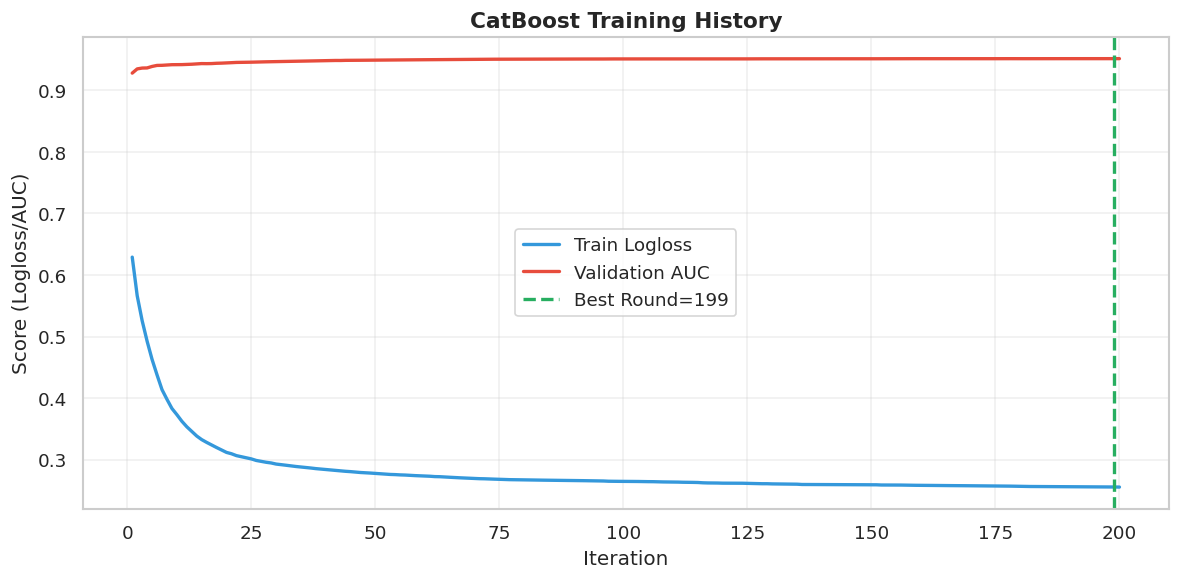

In [44]:
evals_result = cb_best.evals_result_

fig, ax = plt.subplots(figsize=(10, 5))

train_logloss = evals_result['learn']['Logloss'] # Changed from AUC to Logloss
valid_auc = evals_result['validation']['AUC']
rounds    = range(1, len(train_logloss) + 1) # Use train_logloss for length

ax.plot(rounds, train_logloss,
        color='#3498db', lw=2,
        label='Train Logloss') # Updated label
ax.plot(rounds, valid_auc,
        color='#e74c3c', lw=2,
        label='Validation AUC')
best_round = np.argmax(valid_auc) + 1
ax.axvline(x=best_round,
           color='#27ae60',
           linestyle='--', lw=2,
           label=f'Best Round={best_round}')
ax.set_title('CatBoost Training History',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Iteration')
ax.set_ylabel('Score (Logloss/AUC)') # Updated y-axis label
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('CB_14_training_history.png',
            bbox_inches='tight')
plt.show()

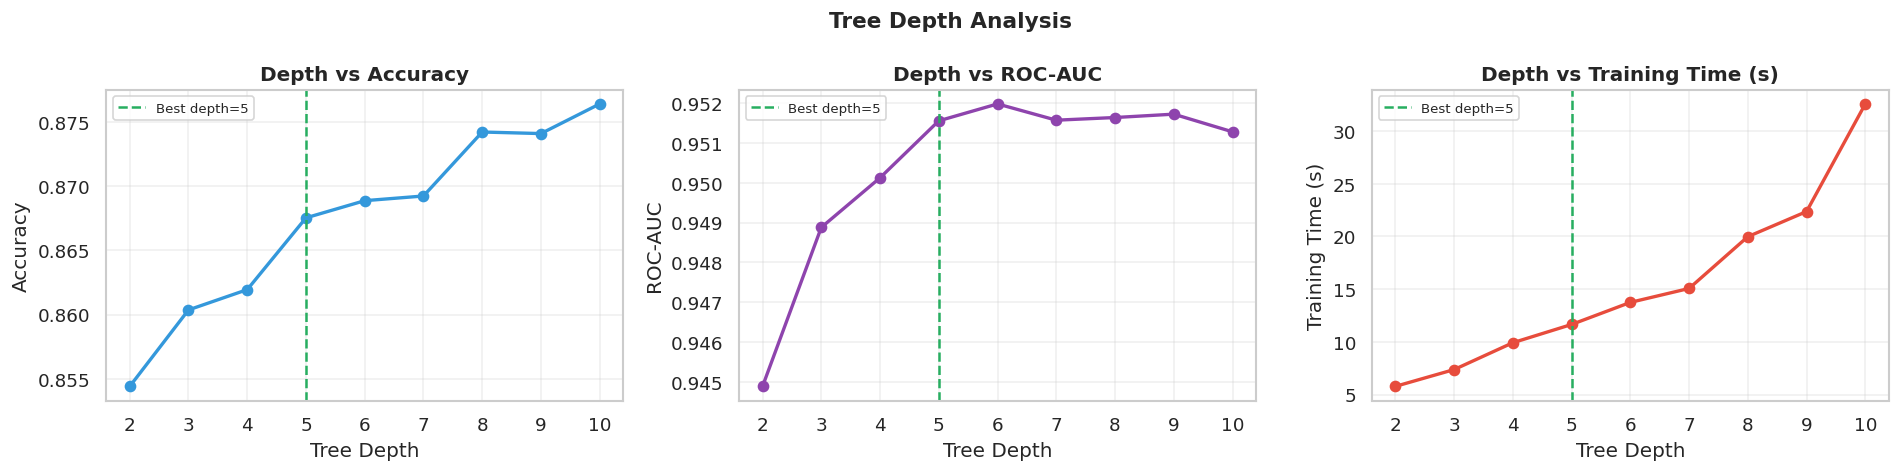

In [45]:
depths     = [2, 3, 4, 5, 6, 7, 8, 9, 10]
depth_acc  = []
depth_roc  = []
depth_time = []

for d in depths:
    start = time.time()
    m = CatBoostClassifier(
        iterations         = grid_search.best_params_[
                                 'iterations'],
        learning_rate      = grid_search.best_params_[
                                 'learning_rate'],
        depth              = d,
        cat_features       = cat_feat_indices,
        auto_class_weights = 'Balanced',
        random_seed        = 42,
        verbose            = 0)
    m.fit(train_pool)
    depth_time.append(time.time() - start)
    depth_acc.append(accuracy_score(
        y_test, m.predict(test_pool)))
    depth_roc.append(roc_auc_score(
        y_test,
        m.predict_proba(test_pool)[:, 1]))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, vals, title, color in zip(
        axes,
        [depth_acc, depth_roc, depth_time],
        ['Accuracy', 'ROC-AUC',
         'Training Time (s)'],
        ['#3498db', '#8e44ad', '#e74c3c']):
    ax.plot(depths, vals,
            'o-', color=color, lw=2)
    ax.axvline(
        x=grid_search.best_params_['depth'],
        color='#27ae60', linestyle='--',
        label=f'Best depth='
              f'{grid_search.best_params_["depth"]}')
    ax.set_title(f'Depth vs {title}',
                 fontweight='bold')
    ax.set_xlabel('Tree Depth')
    ax.set_ylabel(title)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Tree Depth Analysis',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('CB_15_depth_analysis.png',
            bbox_inches='tight')
plt.show()

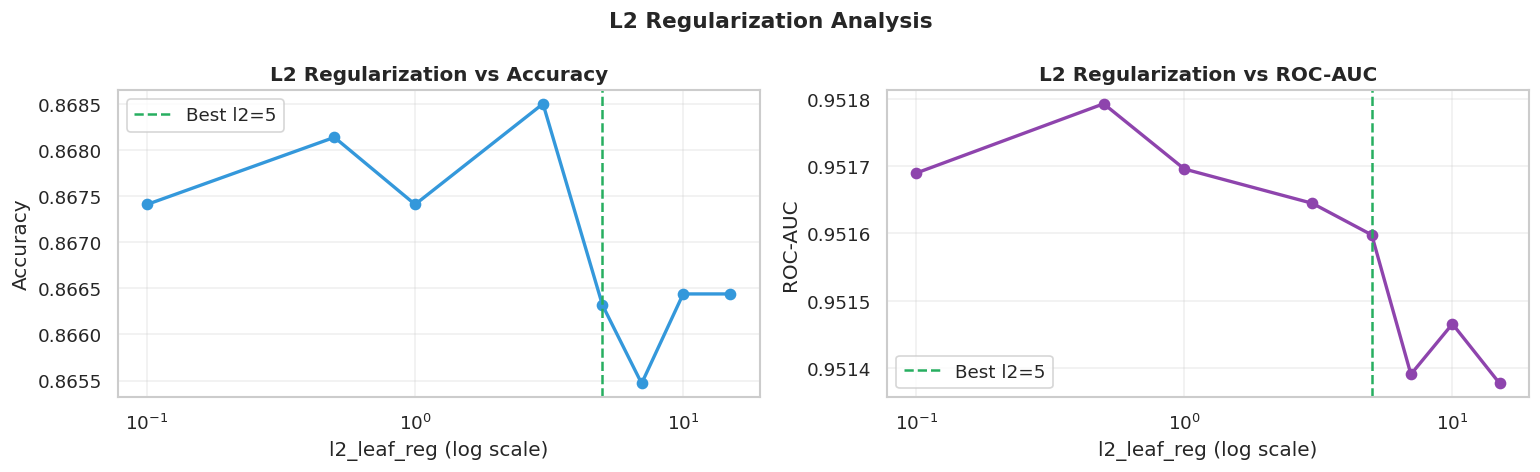

In [47]:
l2_values = [0.1, 0.5, 1, 3, 5, 7, 10, 15]
l2_roc    = []
l2_acc    = []

for l2 in l2_values:
    # Create a mutable copy of best_params_ and remove 'l2_leaf_reg' if present
    params = {k: v for k, v in grid_search.best_params_.items()}
    if 'l2_leaf_reg' in params:
        del params['l2_leaf_reg']

    m = CatBoostClassifier(
        **params, # Unpack modified parameters
        l2_leaf_reg        = l2, # Pass current l2 value
        cat_features       = cat_feat_indices,
        auto_class_weights = 'Balanced',
        random_seed        = 42,
        verbose            = 0)
    m.fit(train_pool)
    l2_acc.append(accuracy_score(
        y_test, m.predict(test_pool)))
    l2_roc.append(roc_auc_score(
        y_test,
        m.predict_proba(test_pool)[:, 1]))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, vals, title, color in zip(
        axes,
        [l2_acc, l2_roc],
        ['Accuracy', 'ROC-AUC'],
        ['#3498db', '#8e44ad']):
    ax.semilogx(l2_values, vals,
                'o-', color=color, lw=2)
    ax.axvline(
        x=grid_search.best_params_[
            'l2_leaf_reg'],
        color='#27ae60', linestyle='--',
        label=f'Best l2='
              f'{grid_search.best_params_["l2_leaf_reg"]}')
    ax.set_title(f'L2 Regularization vs {title}',
                 fontweight='bold')
    ax.set_xlabel('l2_leaf_reg (log scale)')
    ax.set_ylabel(title)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('L2 Regularization Analysis',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('CB_16_l2_analysis.png',
            bbox_inches='tight')
plt.show()

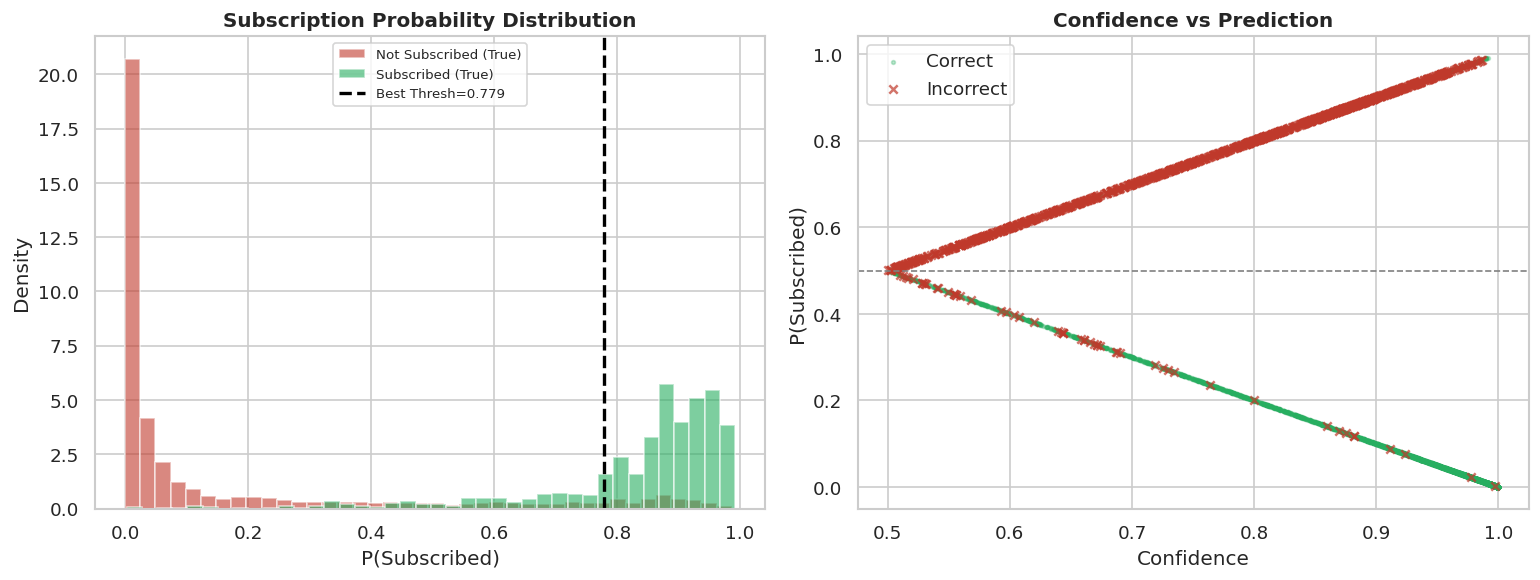

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(
    y_pred_prob[y_test == 0],
    bins=40, alpha=0.6,
    color='#c0392b',
    label='Not Subscribed (True)',
    density=True)
axes[0].hist(
    y_pred_prob[y_test == 1],
    bins=40, alpha=0.6,
    color='#27ae60',
    label='Subscribed (True)',
    density=True)
axes[0].axvline(x=best_thresh,
                color='black',
                linestyle='--', lw=2,
                label=f'Best Thresh='
                      f'{best_thresh:.3f}')
axes[0].set_title(
    'Subscription Probability Distribution',
    fontsize=12, fontweight='bold')
axes[0].set_xlabel('P(Subscribed)')
axes[0].set_ylabel('Density')
axes[0].legend(fontsize=8)

correct_mask = (y_pred == y_test.values)
confidence   = np.maximum(
    y_pred_prob, 1 - y_pred_prob)

axes[1].scatter(
    confidence[correct_mask],
    y_pred_prob[correct_mask],
    alpha=0.3, s=5,
    color='#27ae60', label='Correct')
axes[1].scatter(
    confidence[~correct_mask],
    y_pred_prob[~correct_mask],
    alpha=0.7, s=25,
    color='#c0392b',
    label='Incorrect', marker='x')
axes[1].axhline(y=0.5, color='gray',
                linestyle='--', lw=1)
axes[1].set_title(
    'Confidence vs Prediction',
    fontsize=12, fontweight='bold')
axes[1].set_xlabel('Confidence')
axes[1].set_ylabel('P(Subscribed)')
axes[1].legend()

plt.tight_layout()
plt.savefig('CB_17_prob_distribution.png',
            bbox_inches='tight')
plt.show()

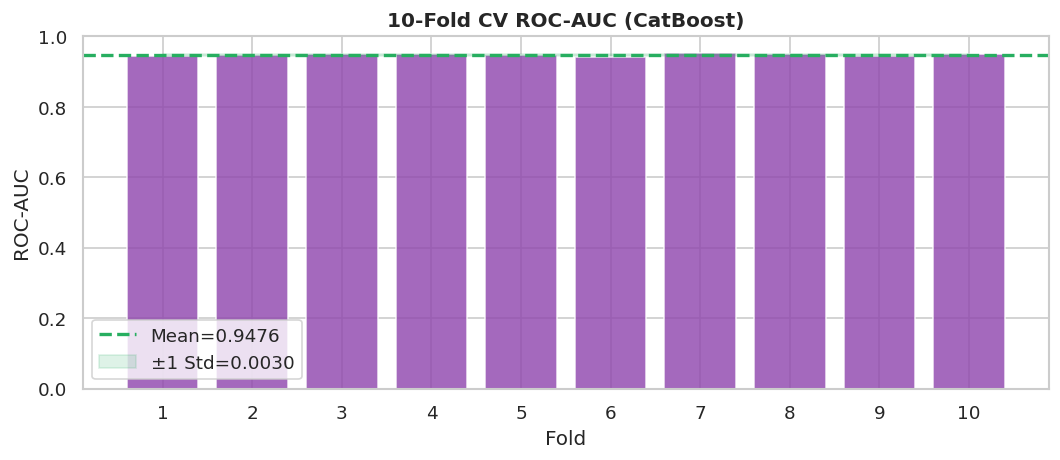

In [50]:
from sklearn.base import clone

# Manual cross-validation due to cross_val_score limitations with CatBoost
# (cat_features needs to be passed to fit, which cross_val_score doesn't facilitate directly)

skf = StratifiedKFold(10, shuffle=True, random_state=42) # Added shuffle and random_state for reproducibility
cv_scores_10 = []

for train_idx, val_idx in skf.split(X_train, y_train):
    X_train_fold, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_train_fold, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]

    cb_fold = clone(cb_best) # Clone the estimator without cat_features in constructor
    cb_fold.fit(X_train_fold, y_train_fold, cat_features=cat_feat_indices) # Pass cat_features to fit
    y_pred_proba_fold = cb_fold.predict_proba(X_val_fold)[:, 1]
    cv_scores_10.append(roc_auc_score(y_val_fold, y_pred_proba_fold))

cv_scores_10 = np.array(cv_scores_10)

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(range(1, 11), cv_scores_10,
       color='#8e44ad',
       edgecolor='white', alpha=0.8)
ax.axhline(y=cv_scores_10.mean(),
           color='#27ae60',
           linestyle='--', lw=2,
           label=f'Mean='
                 f'{cv_scores_10.mean():.4f}')
ax.fill_between(
    range(1, 11),
    cv_scores_10.mean() - cv_scores_10.std(),
    cv_scores_10.mean() + cv_scores_10.std(),
    alpha=0.15, color='#27ae60',
    label=f'±1 Std='
          f'{cv_scores_10.std():.4f}')
ax.set_title('10-Fold CV ROC-AUC (CatBoost)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Fold')
ax.set_ylabel('ROC-AUC')
ax.set_xticks(range(1, 11))
ax.legend()
plt.tight_layout()
plt.savefig('CB_18_cv_scores.png',
            bbox_inches='tight')
plt.show()

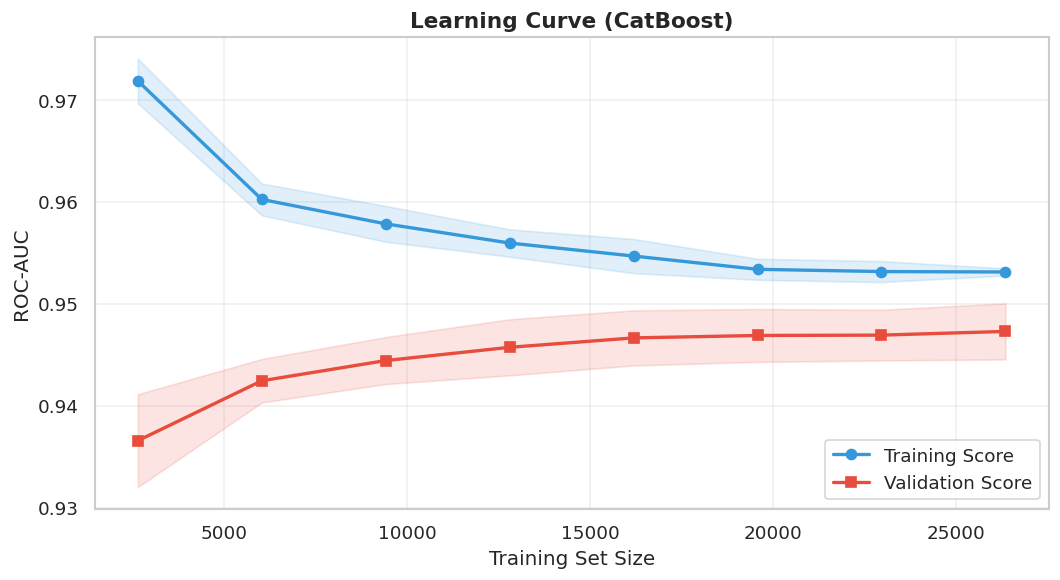

In [52]:
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import numpy as np

# Define parameters for the learning curve
train_sizes_ratios = np.linspace(0.1, 1.0, 8)
n_splits = 5
cv_splitter = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# Initialize lists to store scores
all_train_scores_per_size = [] # List of lists, each sublist contains scores for a given train_size across folds
all_val_scores_per_size = []   # Same for validation scores
actual_train_samples_per_size = [] # List of actual sample counts for each train_size

for train_size_ratio in train_sizes_ratios:
    current_train_scores_folds = []
    current_val_scores_folds = []
    current_actual_train_samples_in_fold = []

    for fold_train_idx, fold_val_idx in cv_splitter.split(X_train, y_train):
        # Calculate the number of samples for the current training subset
        num_total_train_samples_in_fold = len(fold_train_idx)
        num_samples_for_subset = max(1, int(num_total_train_samples_in_fold * train_size_ratio)) # Ensure at least 1 sample

        # Randomly select subset for training from the fold's training indices
        # Ensure reproducibility for sampling subset
        rng = np.random.RandomState(42) # Use a fixed random state for reproducible sampling
        subset_train_idx = rng.choice(fold_train_idx, num_samples_for_subset, replace=False)

        X_train_subset, y_train_subset = X_train.iloc[subset_train_idx], y_train.iloc[subset_train_idx]
        X_val_fold, y_val_fold = X_train.iloc[fold_val_idx], y_train.iloc[fold_val_idx]

        cb_fold = clone(cb_best)
        cb_fold.fit(X_train_subset, y_train_subset, cat_features=cat_feat_indices)

        # Predict probabilities and calculate ROC-AUC for training subset
        train_prob = cb_fold.predict_proba(X_train_subset)[:, 1]
        current_train_scores_folds.append(roc_auc_score(y_train_subset, train_prob))

        # Predict probabilities and calculate ROC-AUC for validation fold
        val_prob = cb_fold.predict_proba(X_val_fold)[:, 1]
        current_val_scores_folds.append(roc_auc_score(y_val_fold, val_prob))

        current_actual_train_samples_in_fold.append(num_samples_for_subset)

    all_train_scores_per_size.append(current_train_scores_folds)
    all_val_scores_per_size.append(current_val_scores_folds)
    # Store the actual number of training samples (average across folds) for each train_size_ratio
    actual_train_samples_per_size.append(np.mean(current_actual_train_samples_in_fold))

# Convert to numpy arrays
train_sc = np.array(all_train_scores_per_size) # Shape: (num_train_sizes, num_folds)
val_sc = np.array(all_val_scores_per_size)     # Shape: (num_train_sizes, num_folds)
train_sizes = np.array(actual_train_samples_per_size) # Shape: (num_train_sizes,)

# Now calculate mean and std as in the original code
train_mean = train_sc.mean(axis=1)
train_std  = train_sc.std(axis=1)
val_mean   = val_sc.mean(axis=1)
val_std    = val_sc.std(axis=1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(train_sizes, train_mean,
        'o-', color='#3498db', lw=2,
        label='Training Score')
ax.fill_between(
    train_sizes,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.15, color='#3498db')
ax.plot(train_sizes, val_mean,
        's-', color='#e74c3c', lw=2,
        label='Validation Score')
ax.fill_between(
    train_sizes,
    val_mean - val_std,
    val_mean + val_std,
    alpha=0.15, color='#e74c3c')
ax.set_title('Learning Curve (CatBoost)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Training Set Size')
ax.set_ylabel('ROC-AUC')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('CB_19_learning_curve.png',
            bbox_inches='tight')
plt.show()

  CatBoost        → Train: 3.24s  Pred: 0.006s  ROC: 0.9501
  LightGBM        → Train: 0.40s  Pred: 0.028s  ROC: 0.9491
  XGBoost         → Train: 0.71s  Pred: 0.019s  ROC: 0.9462
  GradBoost       → Train: 5.43s  Pred: 0.013s  ROC: 0.9499


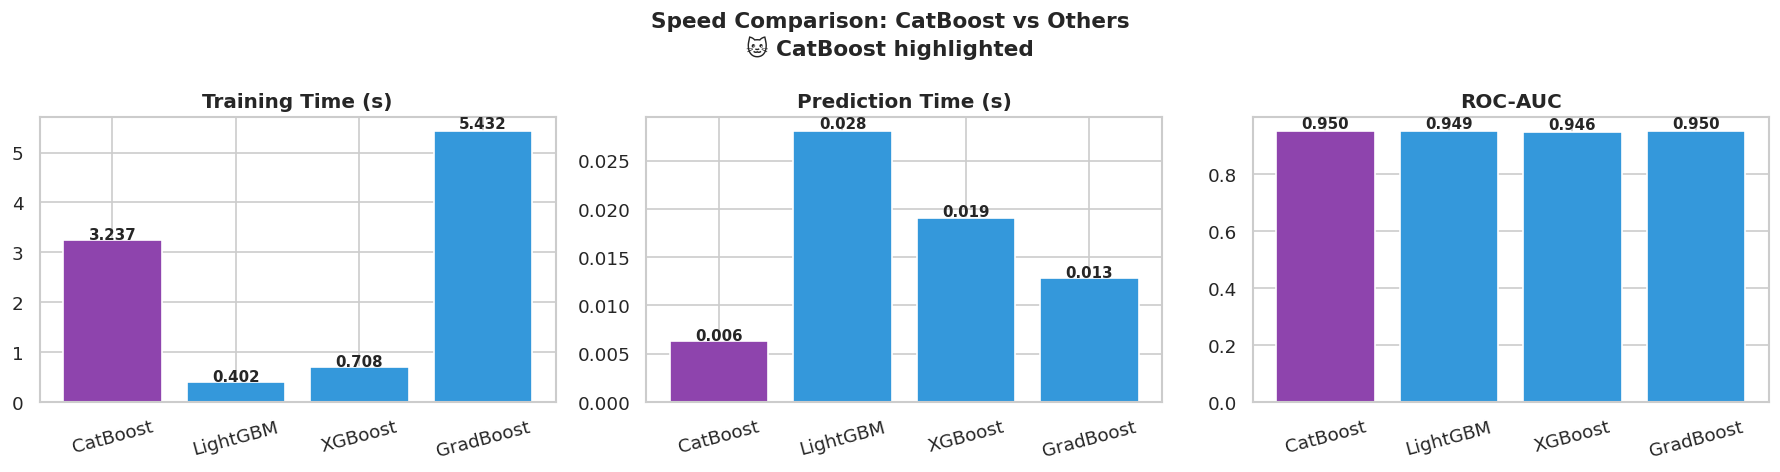

In [53]:
from sklearn.ensemble import (
    GradientBoostingClassifier)

speed_models = {
    'CatBoost': CatBoostClassifier(
        iterations   = 100,
        random_seed  = 42,
        verbose      = 0,
        cat_features = cat_feat_indices),
}

try:
    from lightgbm import LGBMClassifier
    speed_models['LightGBM'] = LGBMClassifier(
        n_estimators = 100,
        random_state = 42,
        n_jobs       = -1,
        verbose      = -1)
except:
    pass

try:
    from xgboost import XGBClassifier
    speed_models['XGBoost'] = XGBClassifier(
        n_estimators      = 100,
        random_state      = 42,
        n_jobs            = -1,
        use_label_encoder = False,
        eval_metric       = 'logloss',
        verbosity         = 0)
except:
    pass

speed_models['GradBoost'] = \
    GradientBoostingClassifier(
        n_estimators = 100,
        random_state = 42)

# Encode X for non-CatBoost models
X_train_enc = X_train.copy()
X_test_enc  = X_test.copy()
for col in cat_feature_cols_model:
    if col in X_train_enc.columns:
        le_temp = LabelEncoder()
        X_train_enc[col] = le_temp.fit_transform(
            X_train_enc[col].astype(str))
        X_test_enc[col]  = le_temp.transform(
            X_test_enc[col].astype(str))

speed_res = {}
for name, model in speed_models.items():
    if name == 'CatBoost':
        start = time.time()
        model.fit(train_pool)
        t_time = time.time() - start
        start = time.time()
        preds  = model.predict(test_pool)
        p_time = time.time() - start
        roc_s  = roc_auc_score(
            y_test,
            model.predict_proba(
                test_pool)[:, 1])
    else:
        start = time.time()
        model.fit(X_train_enc, y_train)
        t_time = time.time() - start
        start = time.time()
        model.predict(X_test_enc)
        p_time = time.time() - start
        roc_s  = roc_auc_score(
            y_test,
            model.predict_proba(
                X_test_enc)[:, 1])

    speed_res[name] = {
        'train_time': t_time,
        'pred_time' : p_time,
        'roc_auc'   : roc_s}
    print(f"  {name:<15} → "
          f"Train: {t_time:.2f}s  "
          f"Pred: {p_time:.3f}s  "
          f"ROC: {roc_s:.4f}")

# Speed plot
fig, axes = plt.subplots(
    1, 3, figsize=(15, 4))
names_s  = list(speed_res.keys())
t_times  = [speed_res[n]['train_time']
            for n in names_s]
p_times  = [speed_res[n]['pred_time']
            for n in names_s]
rocs_s   = [speed_res[n]['roc_auc']
            for n in names_s]
clrs_s   = ['#8e44ad' if n == 'CatBoost'
            else '#3498db'
            for n in names_s]

for ax, vals, title in zip(
        axes,
        [t_times, p_times, rocs_s],
        ['Training Time (s)',
         'Prediction Time (s)',
         'ROC-AUC']):
    bars = ax.bar(names_s, vals,
                  color=clrs_s,
                  edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() +
            bar.get_width()/2,
            bar.get_height() * 1.01,
            f'{val:.3f}',
            ha='center', fontsize=9,
            fontweight='bold')

plt.suptitle(
    'Speed Comparison: CatBoost vs Others\n'
    '🐱 CatBoost highlighted',
    fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('CB_20_speed_comparison.png',
            bbox_inches='tight')
plt.show()

In [54]:
y_pred_opt = (
    y_pred_prob >= best_thresh
).astype(int)

acc_opt = accuracy_score(y_test, y_pred_opt)

print(f"Default  Threshold (0.50) → "
      f"Accuracy: {acc*100:.2f}%")
print(f"Optimal  Threshold "
      f"({best_thresh:.3f}) → "
      f"Accuracy: {acc_opt*100:.2f}%")

print(f"\n📋 Report (Optimal Threshold):\n")
print(classification_report(
    y_test, y_pred_opt,
    target_names=['Not Subscribed',
                  'Subscribed']))

Default  Threshold (0.50) → Accuracy: 86.63%
Optimal  Threshold (0.779) → Accuracy: 90.98%

📋 Report (Optimal Threshold):

                precision    recall  f1-score   support

Not Subscribed       0.97      0.92      0.95      7308
    Subscribed       0.57      0.81      0.67       928

      accuracy                           0.91      8236
     macro avg       0.77      0.87      0.81      8236
  weighted avg       0.93      0.91      0.92      8236



In [55]:
# ── Save CatBoost native format
cb_best.save_model('cb_bank_model.cbm')
print("✅ CatBoost Model (cbm) → "
      "cb_bank_model.cbm")

# ── Save sklearn pkl format
joblib.dump(cb_best,
            'cb_bank_model.pkl')
print("✅ CatBoost Model (pkl) → "
      "cb_bank_model.pkl")

# ── Save JSON format
cb_best.save_model(
    'cb_bank_model.json',
    format='json')
print("✅ CatBoost Model (json)→ "
      "cb_bank_model.json")

# ── Save scaler
scaler = StandardScaler()
scaler.fit(X_train.select_dtypes(
    include=[np.number]))
joblib.dump(scaler, 'CB_scaler.pkl')
print("✅ Scaler               → CB_scaler.pkl")

# ── Save feature names
pd.DataFrame({
    'feature'        : list(X.columns),
    'is_categorical' : [
        c in cat_feature_cols_model
        for c in X.columns]
}).to_csv('CB_feature_names.csv', index=False)
print("✅ Feature names        → "
      "CB_feature_names.csv")

# ── Save feature importances
fi_df = pd.DataFrame({
    'Feature'          : feature_names,
    'PredValChange_Imp': imp_pred,
    'LossChange_Imp'   : imp_loss,
    'Permutation_Imp'  : perm_imp.importances_mean
}).sort_values('LossChange_Imp',
               ascending=False)
fi_df.to_csv(
    'CB_feature_importances.csv', index=False)
print("✅ Feature importances  → "
      "CB_feature_importances.csv")

# ── Save Native CV results
cv_results.to_csv(
    'CB_native_cv_results.csv', index=False)
print("✅ Native CV results    → "
      "CB_native_cv_results.csv")

# ── Save GridSearch results
pd.DataFrame(
    grid_search.cv_results_
).to_csv('CB_gridsearch_results.csv',
         index=False)
print("✅ GridSearch results   → "
      "CB_gridsearch_results.csv")

# ── Save threshold analysis
pd.DataFrame({
    'threshold': thresholds,
    'precision': precision[:-1],
    'recall'   : recall[:-1],
    'f1'       : f1
}).to_csv('CB_threshold_analysis.csv',
          index=False)
print("✅ Threshold analysis   → "
      "CB_threshold_analysis.csv")

# ── Save speed comparison
pd.DataFrame(speed_res).T.to_csv(
    'CB_speed_comparison.csv')
print("✅ Speed comparison     → "
      "CB_speed_comparison.csv")

# ── Download in Google Colab ─────────────────
try:
    from google.colab import files
    for f in [
        'cb_bank_model.cbm',
        'cb_bank_model.pkl',
        'cb_bank_model.json',
        'CB_scaler.pkl',
        'CB_feature_names.csv',
        'CB_feature_importances.csv',
        'CB_native_cv_results.csv',
        'CB_gridsearch_results.csv',
        'CB_threshold_analysis.csv',
        'CB_speed_comparison.csv']:
        files.download(f)
    print("\n🎉 All files downloaded!")
except ImportError:
    print("\n📁 Saved locally:")
    print(f"   → "
          f"{os.path.abspath('cb_bank_model.cbm')}")
    print(f"   → "
          f"{os.path.abspath('cb_bank_model.pkl')}")
    print(f"   → "
          f"{os.path.abspath('cb_bank_model.json')}")

✅ CatBoost Model (cbm) → cb_bank_model.cbm
✅ CatBoost Model (pkl) → cb_bank_model.pkl
✅ CatBoost Model (json)→ cb_bank_model.json
✅ Scaler               → CB_scaler.pkl
✅ Feature names        → CB_feature_names.csv
✅ Feature importances  → CB_feature_importances.csv
✅ Native CV results    → CB_native_cv_results.csv
✅ GridSearch results   → CB_gridsearch_results.csv
✅ Threshold analysis   → CB_threshold_analysis.csv
✅ Speed comparison     → CB_speed_comparison.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🎉 All files downloaded!


In [56]:
# Load .cbm (native)
loaded_cbm = CatBoostClassifier()
loaded_cbm.load_model('cb_bank_model.cbm')

# Load .pkl
loaded_pkl = joblib.load('cb_bank_model.pkl')

# Load .json
loaded_json = CatBoostClassifier()
loaded_json.load_model(
    'cb_bank_model.json', format='json')

sample_pool = Pool(
    data         = X_test.iloc[:6],
    cat_features = cat_feat_indices)

predictions = loaded_cbm.predict(sample_pool)
proba       = loaded_cbm.predict_proba(
    sample_pool)[:, 1]
pred_opt    = (
    proba >= best_thresh).astype(int)
actuals     = y_test.values[:6]

print("\n📊 Predictions (3 Loaded Formats):")
print(f"{'#':<4} {'Default(0.5)':<18} "
      f"{'Optimal':<18} "
      f"{'P(Sub)':>8} {'Actual':>15}")
print("-" * 68)

for i, (pred, pred_o,
        prob, actual) in enumerate(
        zip(predictions, pred_opt,
            proba, actuals)):
    d_lbl = ("🟢 SUBSCRIBED"
             if pred   == 1
             else "🔴 NOT SUBSCRIBED")
    o_lbl = ("🟢 SUBSCRIBED"
             if pred_o == 1
             else "🔴 NOT SUBSCRIBED")
    a_lbl = ("SUBSCRIBED"
             if actual == 1
             else "NOT SUBSCRIBED")
    ok    = "✅" if pred_o == actual else "❌"
    print(f"{i+1:<4} {d_lbl:<18} "
          f"{o_lbl:<18} "
          f"{prob*100:>7.2f}% "
          f"{a_lbl:>14} {ok}")

# Verify all 3 formats give same result
pred_pkl  = loaded_pkl.predict_proba(
    sample_pool)[:, 1]
pred_json = loaded_json.predict_proba(
    sample_pool)[:, 1]

print(f"\n✅ All 3 formats give same result: "
      f"{np.allclose(proba, pred_pkl) and np.allclose(proba, pred_json)}")


📊 Predictions (3 Loaded Formats):
#    Default(0.5)       Optimal              P(Sub)          Actual
--------------------------------------------------------------------
1    🔴 NOT SUBSCRIBED   🔴 NOT SUBSCRIBED      1.00% NOT SUBSCRIBED ✅
2    🟢 SUBSCRIBED       🟢 SUBSCRIBED         97.13%     SUBSCRIBED ✅
3    🔴 NOT SUBSCRIBED   🔴 NOT SUBSCRIBED     11.56% NOT SUBSCRIBED ✅
4    🟢 SUBSCRIBED       🔴 NOT SUBSCRIBED     55.81% NOT SUBSCRIBED ✅
5    🔴 NOT SUBSCRIBED   🔴 NOT SUBSCRIBED      0.29% NOT SUBSCRIBED ✅
6    🔴 NOT SUBSCRIBED   🔴 NOT SUBSCRIBED      2.07% NOT SUBSCRIBED ✅

✅ All 3 formats give same result: True


In [57]:
print(f"  Dataset                : Bank Marketing")
print(f"  Dataset Shape          : {df.shape}")
print(f"  Features Used          : {X.shape[1]}")
print(f"  Categorical Features   : "
      f"{len(cat_feat_indices)}")
print(f"  Training Samples       : "
      f"{X_train.shape[0]:,}")
print(f"  Test Samples           : "
      f"{X_test.shape[0]:,}")
print(f"  Subscription Rate      : "
      f"{y.mean()*100:.1f}%")
print(f"  Best Parameters        : "
      f"{grid_search.best_params_}")
print(f"  Baseline Accuracy      : "
      f"{acc_base*100:.2f}%")
print(f"  Tuned Accuracy         : "
      f"{acc*100:.2f}%")
print(f"  Baseline ROC-AUC       : "
      f"{roc_base:.4f}")
print(f"  Tuned ROC-AUC          : "
      f"{roc:.4f}")
print(f"  PR-AUC                 : {apr:.4f}")
print(f"  CV ROC-AUC             : "
      f"{cv.mean():.4f} ± {cv.std():.4f}")
print(f"  Best F1 Threshold      : "
      f"{best_thresh:.4f}")
print(f"  Native CV Best Iter    : {best_iter}")
print(f"  Native CV Best AUC     : "
      f"{best_cv_auc:.4f}")

print(" Saved Files:")
print("   cb_bank_model.cbm   ← native format")
print("   cb_bank_model.pkl   ← sklearn format")
print("   cb_bank_model.json  ← json format")
print("   CB_scaler.pkl")
print("   CB_feature_names.csv")
print("   CB_feature_importances.csv")
print("   CB_native_cv_results.csv")
print("   CB_gridsearch_results.csv")
print("   CB_threshold_analysis.csv")
print("   CB_speed_comparison.csv")
print("    CB_01 ~ CB_20 PNG files")


  Dataset                : Bank Marketing
  Dataset Shape          : (41176, 21)
  Features Used          : 26
  Categorical Features   : 11
  Training Samples       : 32,940
  Test Samples           : 8,236
  Subscription Rate      : 11.3%
  Best Parameters        : {'bagging_temperature': 0, 'border_count': 32, 'depth': 5, 'iterations': 200, 'l2_leaf_reg': 5, 'learning_rate': 0.07, 'min_data_in_leaf': 1, 'random_strength': 0}
  Baseline Accuracy      : 87.17%
  Tuned Accuracy         : 86.63%
  Baseline ROC-AUC       : 0.9520
  Tuned ROC-AUC          : 0.9516
  PR-AUC                 : 0.6651
  CV ROC-AUC             : 0.9478 ± 0.0019
  Best F1 Threshold      : 0.7791
  Native CV Best Iter    : 383
  Native CV Best AUC     : 0.9476
 Saved Files:
   cb_bank_model.cbm   ← native format
   cb_bank_model.pkl   ← sklearn format
   cb_bank_model.json  ← json format
   CB_scaler.pkl
   CB_feature_names.csv
   CB_feature_importances.csv
   CB_native_cv_results.csv
   CB_gridsearch_results.cs